# C3M3: Peer Reviewed Assignment

### Outline:
The objectives for this assignment:

1. Implement kernel smoothing in R and interpret the results.

2. Implement smoothing splines as an alternative to kernel estimation.

3. Implement and interpret the loess smoother in R.

4. Compare and contrast nonparametric smoothing methods.


General tips:

1. Read the questions carefully to understand what is being asked.
2. This work will be reviewed by another human, so make sure that you are clear and concise in what your explanations and answers.

In [292]:
# Load Required Packages
library(ggplot2)
library(mgcv)

Loading required package: nlme

This is mgcv 1.8-31. For overview type 'help("mgcv-package")'.



# Problem 1: Advertising data

The following dataset containts measurements related to the impact of three advertising medias on sales of a product, $P$. The variables are:

- `youtube`: the advertising budget allocated to YouTube. Measured in thousands of dollars;

- `facebook`: the advertising budget allocated to Facebook. Measured in thousands of dollars; and 

- `newspaper`: the advertising budget allocated to a local newspaper. Measured in thousands of dollars.

- `sales`: the value in the $i^{th}$ row of the sales column is a measurement of the sales (in thousands of units) for product $P$ for company $i$.

The advertising data treat "a company selling product $P$" as the statistical unit, and "all companies selling product $P$" as the population. We assume that the $n = 200$ companies in the dataset were chosen at random from the population (a strong assumption!).

First, we load the data, plot it, and split it into a training set (`train_marketing`) and a test set (`test_marketing`).

    youtube          facebook       newspaper          sales      
 Min.   :  0.84   Min.   : 0.00   Min.   :  0.36   Min.   : 1.92  
 1st Qu.: 89.25   1st Qu.:11.97   1st Qu.: 15.30   1st Qu.:12.45  
 Median :179.70   Median :27.48   Median : 30.90   Median :15.48  
 Mean   :176.45   Mean   :27.92   Mean   : 36.66   Mean   :16.83  
 3rd Qu.:262.59   3rd Qu.:43.83   3rd Qu.: 54.12   3rd Qu.:20.88  
 Max.   :355.68   Max.   :59.52   Max.   :136.80   Max.   :32.40  

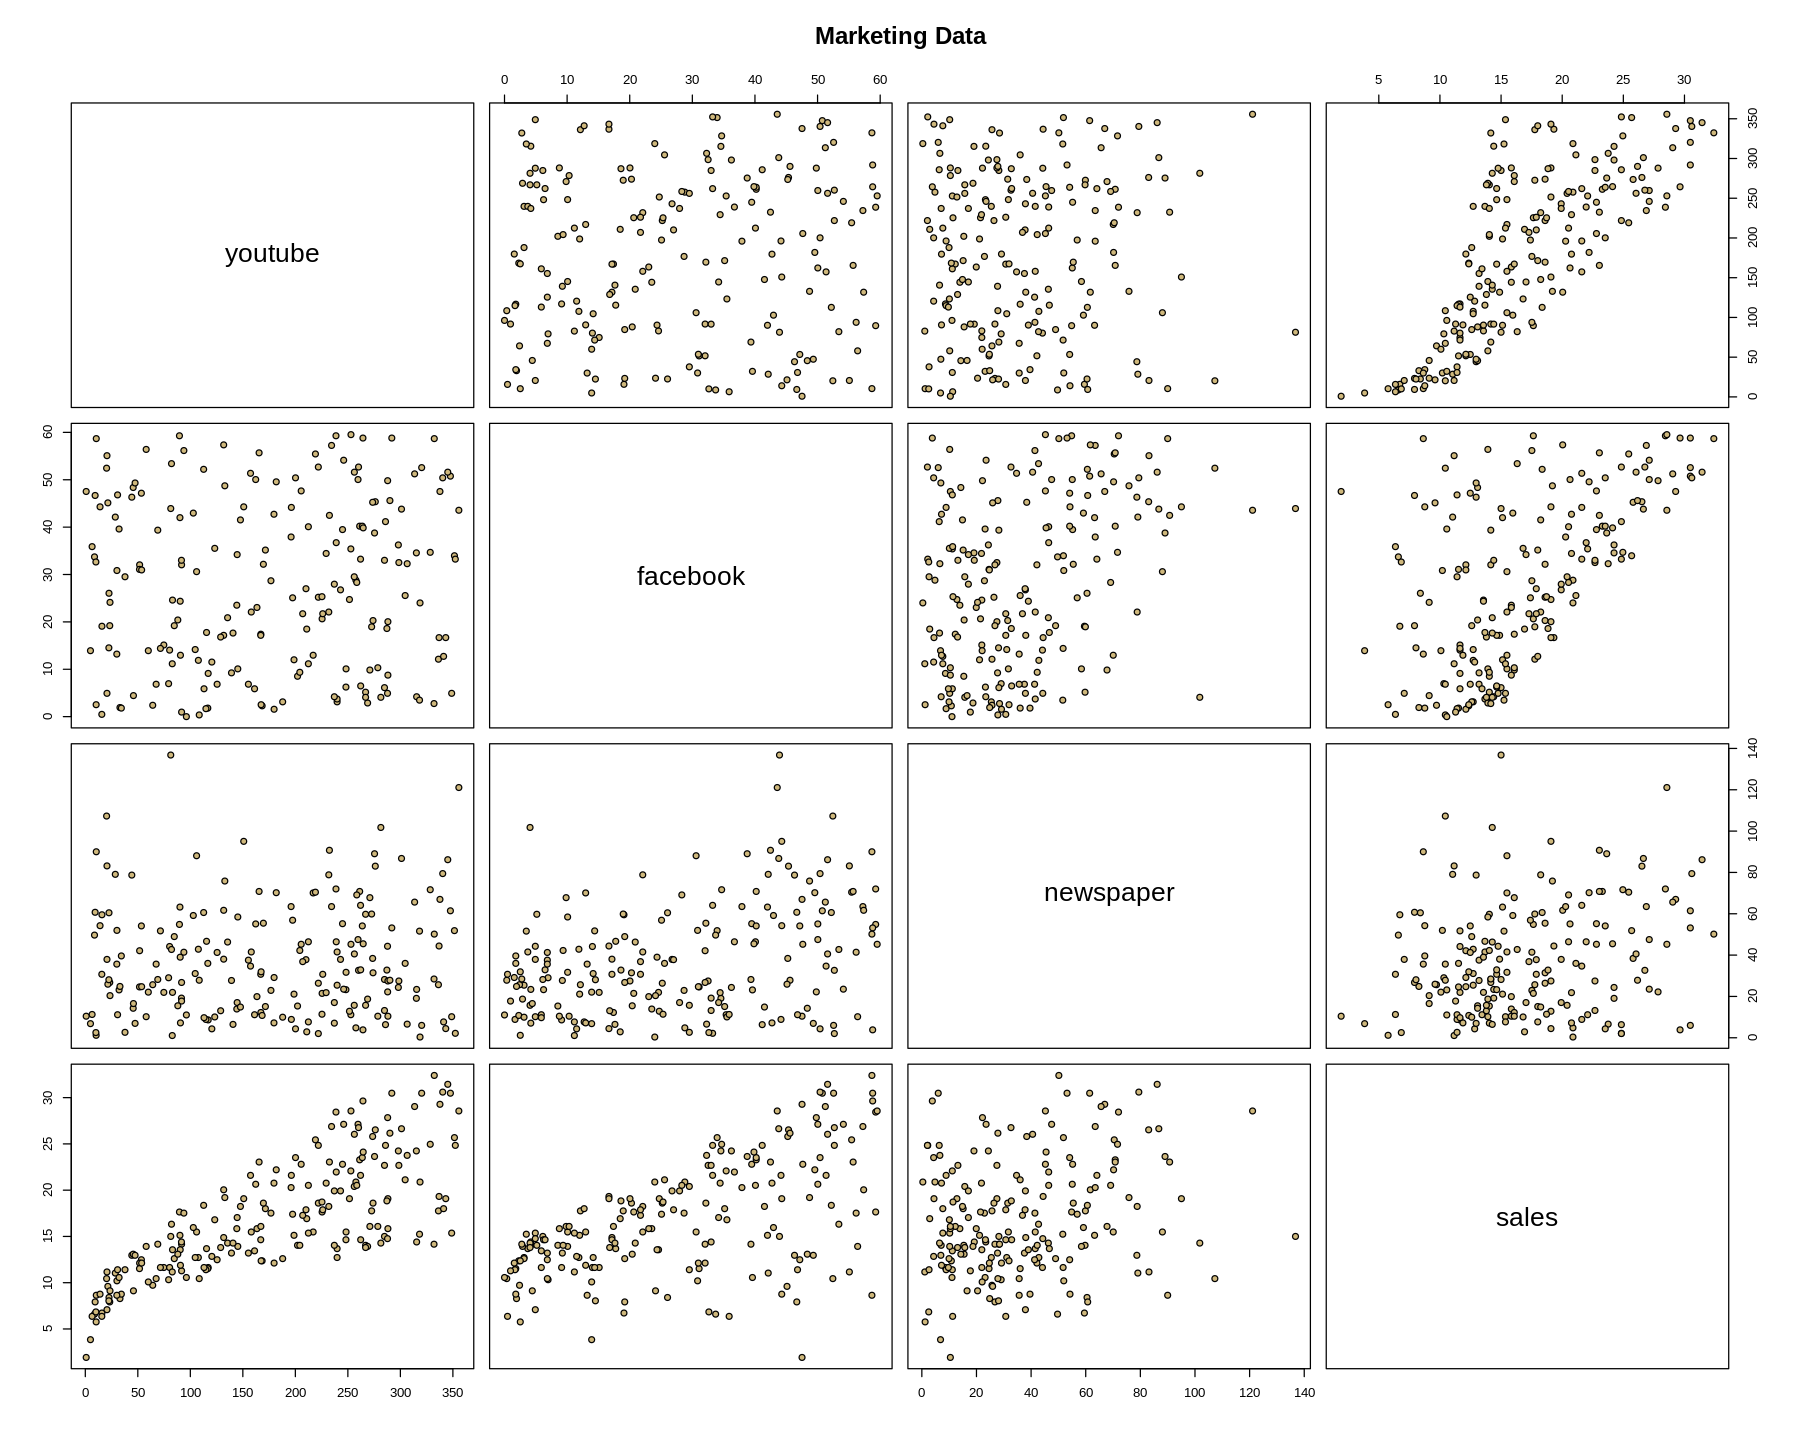

In [293]:
# Load in the data
marketing = read.csv("marketing.txt", sep="")
summary(marketing)
pairs(marketing, main = "Marketing Data", pch = 21, 
      bg = c("#CFB87C"))

In [294]:
set.seed(1771) #set the random number generator seed.
n = floor(0.8 * nrow(marketing)) #find the number corresponding to 80% of the data
index = sample(seq_len(nrow(marketing)), size = n) #randomly sample indicies to be included in the training set

train_marketing = marketing[index, ] #set the training set to be the randomly sampled rows of the dataframe
test_marketing = marketing[-index, ] #set the testing set to be the remaining rows
dim(test_marketing) #check the dimensions
dim(train_marketing) #check the dimensions
head(train_marketing)

[1] 40  4

[1] 160   4

,youtube,facebook,newspaper,sales
,<dbl>,<dbl>,<dbl>,<dbl>
103,336.24,12.12,25.68,17.76
142,232.44,42.48,90.72,23.04
64,123.24,35.52,10.08,16.80
177,298.08,36.24,24.36,24.24
7,69.00,39.36,28.20,14.16
31,351.48,33.96,51.84,25.68


**1.(a) Working with nonlinearity: Kernel regression**

Note that the relationship between `sales` and `youtube` is nonlinear. This was a problem for us back in the first course in this specialization, when we modeled the data as if it were linear. For now, let's just focus on the relationship between `sales` and `youtube`, omitting the other variables (future lessons on generalized additive models will allow us to bring back other predictors).

Using the `train_marketing` set, plot `sales` (response) against `youtube` (predictor), and then fit and overlay a kernel regression. Experiment with the bandwidth parameter until the smooth looks appropriate, or comment why no bandwidth is ideal. Justify your answer.

### Answer:

The function `kernel.regression()` defined in the next code snippet accepts the training and test dataset, along with `kernel` (we used only **Gaussian Kernel**, but others can be tried too) and `bw` (bandwidth) hyperparameters, it iterates over a list of bandwidths, fits a model on the training dataset with a given bandwidth at a time and computes the training and test **RMSE** values with the fitted model. 

The function also plots the fitted values corresponding to kernel regression models with different bandwidths, as shown below. It uses `x.points` argument of the function `ksmooth` to evaluate the fitted model on training dataset and plots the test RMSE corresponding to each model. 

As we can see from the second plot below, we can see there is always a **bias-variance tradeoff** (**underfitting** vs. **overfitting**, i.e., learning too simple or too complex model from the training dataset). It's very difficult to choose the right value of the hyperparameter `bandwidth` simply by looking at the fit. Still lakes make an attempt (somewhat qualitative) based on the complexity of the curve fit (in terms of valriance, how much wiggly or smooth the fitted curve is). 

It seems from the plot that somewhere near bandwidth $8$, the corresponding model looks okay (not very wiggly overfitting the noise and not very simple missing most variance). The model seems to start **overfitting** severely for the hyperparameter value less than this and starts **underfitting** severely for value greater than this.

Also, as we can see the **test RMSE** continuously decreases with increase in bandwidth in the given range of the hyperparameter value.

[1] 160  40

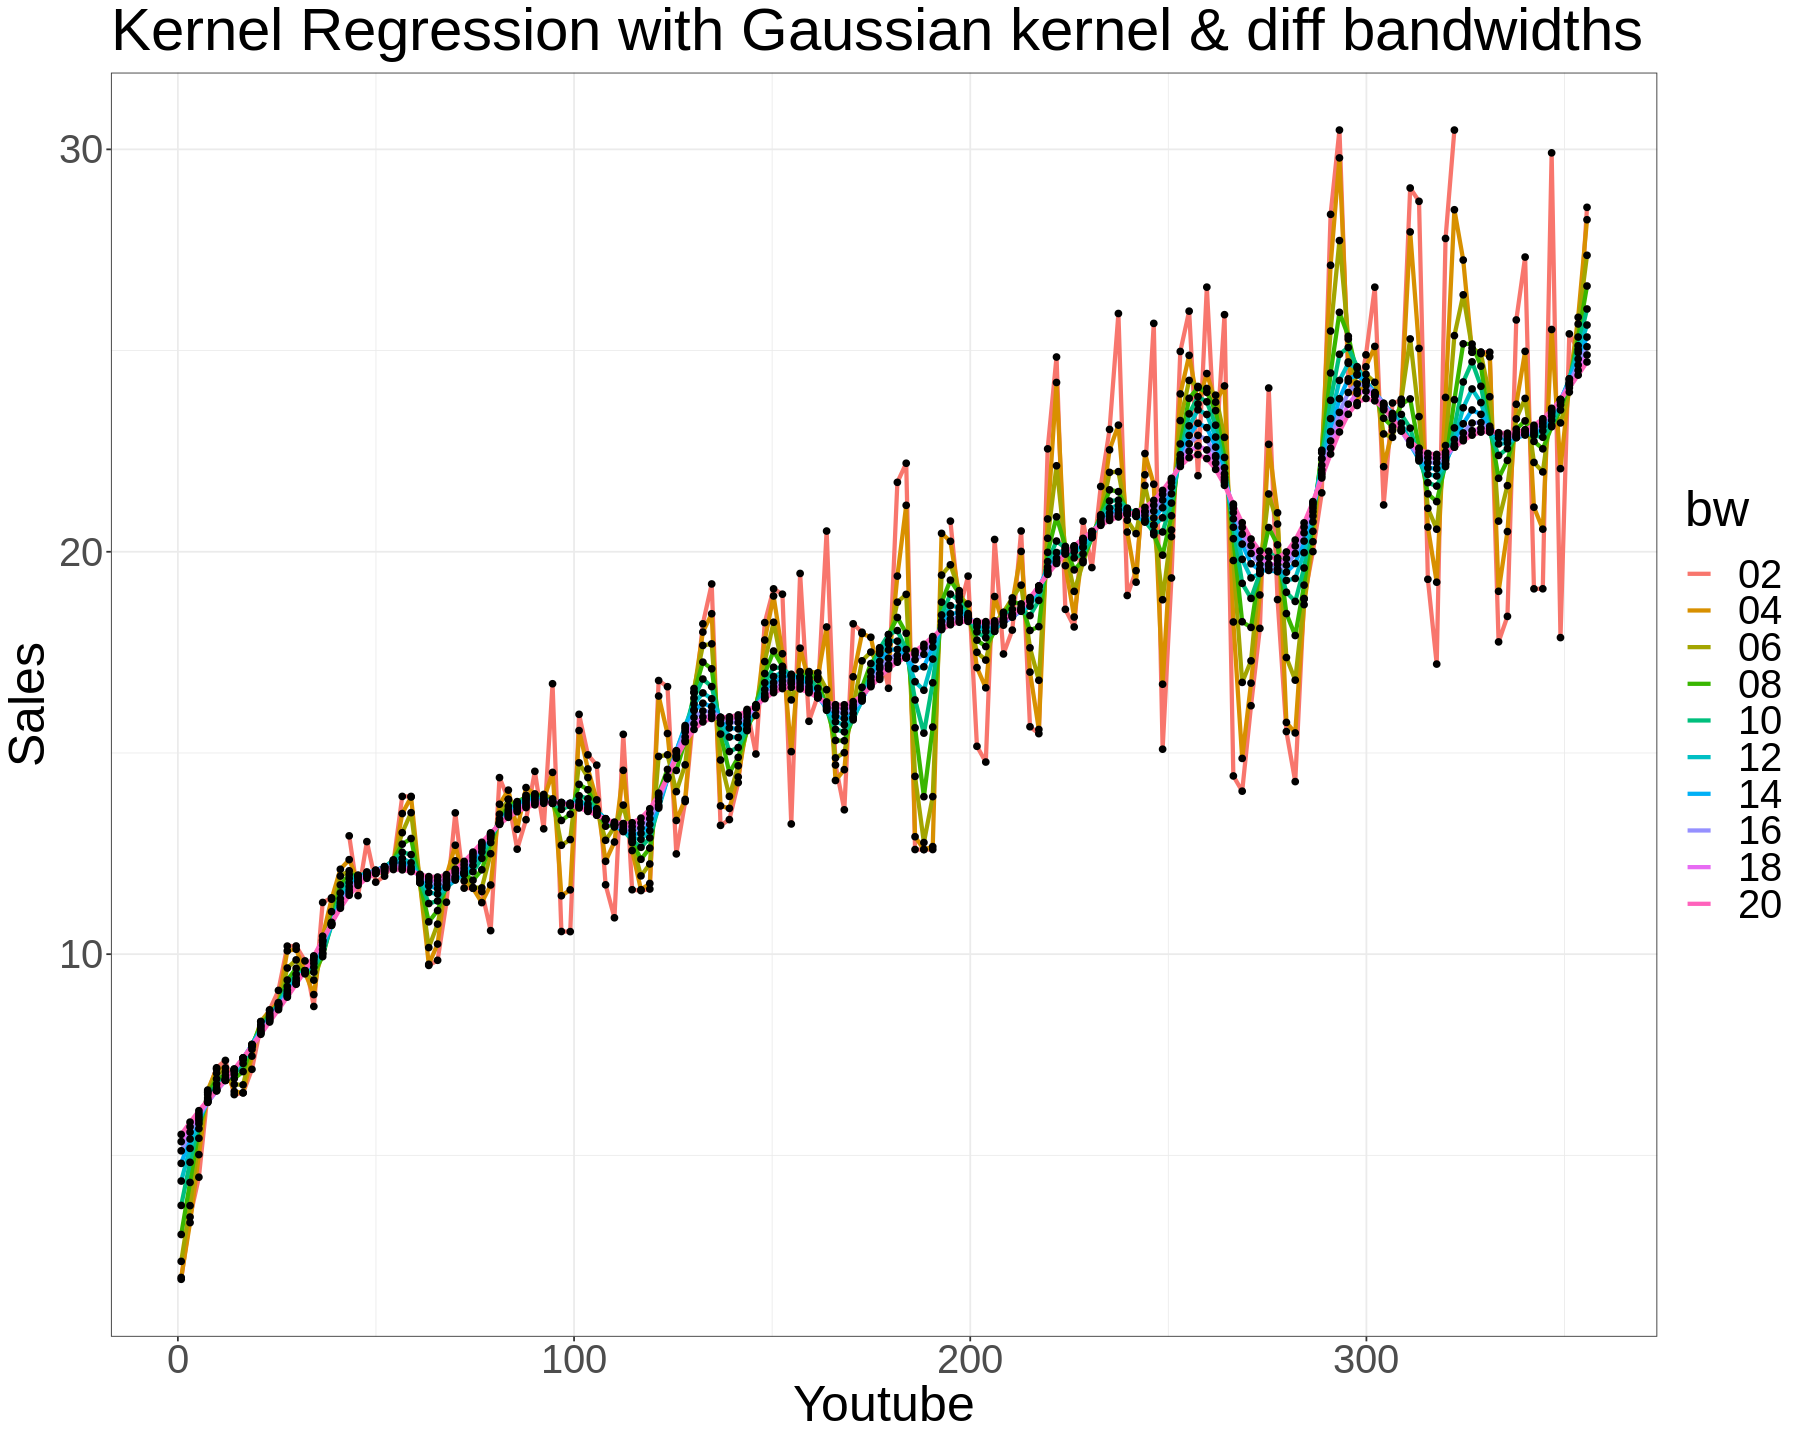

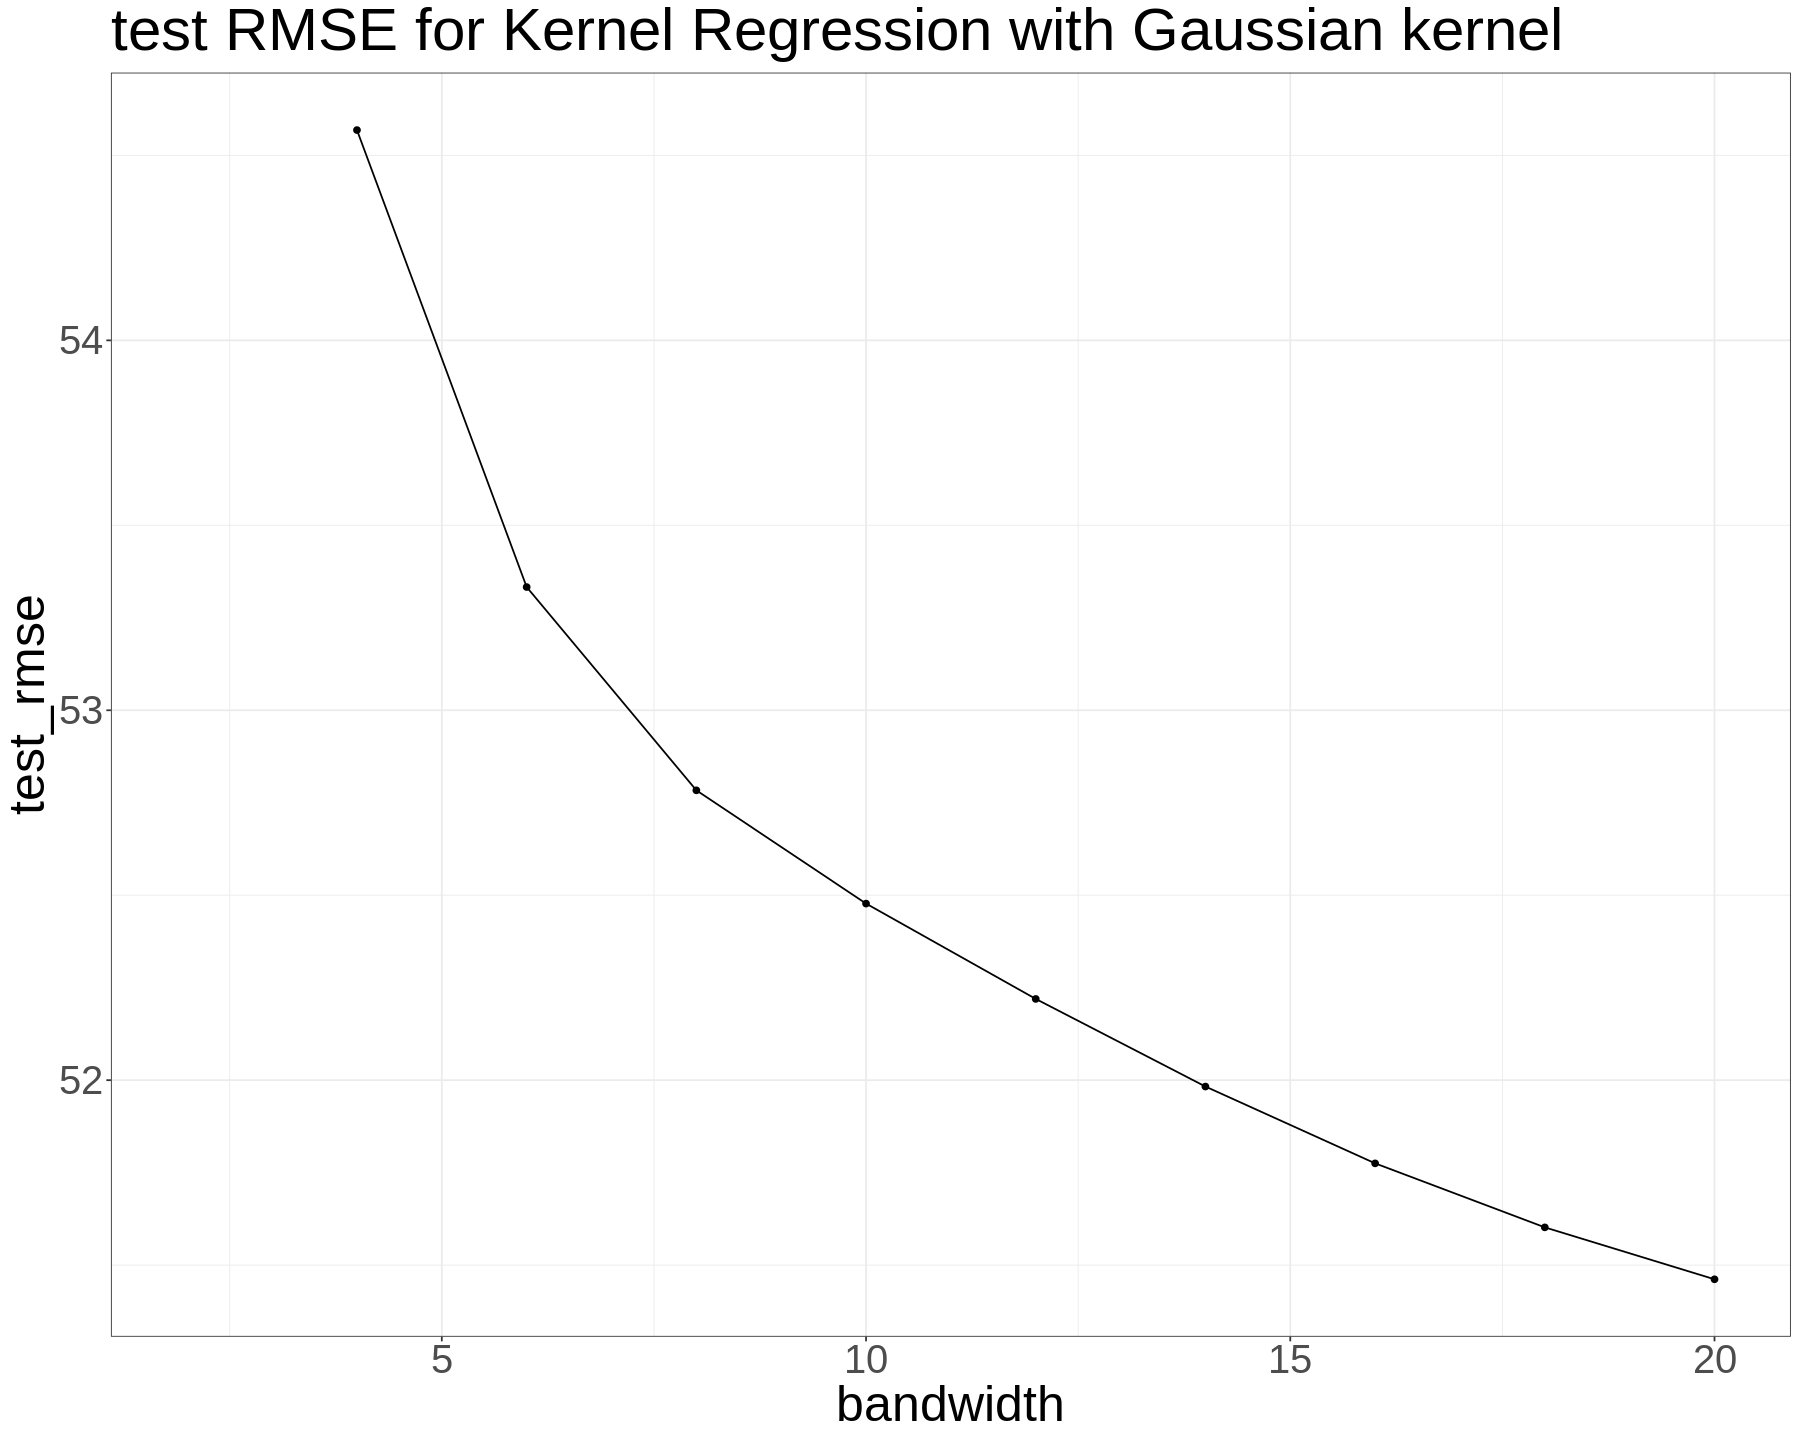

In [319]:
library(ggplot2)
library(repr)
#library(reshape2)
options(repr.plot.width=15, repr.plot.height=12)

x <- train_marketing$youtube
y <- train_marketing$sales
testx <- test_marketing$youtube
testy <- test_marketing$sales

c(length(x), length(testx))

kernel.regression <- function(x, y, testx, testy, kernel, bws) {
      plot.df <- NULL
      test.df <- NULL
      for (bw in bws) {
          res <- ksmooth(x, y, kernel = kernel, bandwidth = bw)
          plot.df <- rbind(plot.df, data.frame(x=res$x, fitted.y=res$y, bw=bw))
          res <- ksmooth(x, y, kernel = kernel, bandwidth = bw, n.points=len(testx), x.points = testx)
          test_rmse <- sqrt(sum((res$y - testy)^2))
          test.df <- rbind(test.df, data.frame(bw=bw, test_rmse=test_rmse))
      }
      plot.df$bw = as.factor(sprintf("%02d", as.integer(plot.df$bw)))
      p <- ggplot(plot.df, aes(x, fitted.y)) + 
           geom_line(aes(col=bw), lwd=1.2) + geom_point(size=1.5) + 
           xlab('Youtube') + ylab('Sales') +
           theme_bw() +
           theme(text=element_text(size=30)) + 
           ggtitle('Kernel Regression with Gaussian kernel & diff bandwidths')
      print(p)
      #print(p, vp=grid::viewport(width=unit(5, 'inch'), height=unit(8, 'inch')))
      return (test.df)
}

test.df <- kernel.regression(x, y, testx, testy, kernel = 'normal', bws = seq(2,20,2))
ggplot(test.df, aes(bw, test_rmse)) + geom_line() + geom_point() + 
    theme_bw() + theme(text=element_text(size=30)) + xlab('bandwidth') +
    ggtitle('test RMSE for Kernel Regression with Gaussian kernel')
#test.df <- melt(test.df, id.vars=c('bw'), variable='split', value.name='rmse')
#ggplot(test.df, aes(bw, rmse, col=split)) + geom_line() + geom_point() + theme_bw() + theme(text=element_text(size=30))

**1.(b) Working with nonlinearity: Smoothing spline regression**

Again, using the `train_marketing` set, plot `sales` (response) against `youtube` (predictor). This time, fit and overlay a smoothing spline regression model. Experiment with the smoothing parameter until the smooth looks appropriate. Explain why it's appropriate and justify your answer.

### Answer:

The function `spline.smooth()` defined in the next code snippet accepts the training and test dataset, along with `spars` (smoothing) hyperparameter, it iterates over a list of values, fits a model on the training dataset with a given `spar` value at a time and computes the cross validation (**cv**) **PRESS** (prediction sum of square) values for the fitted model. 

The function also plots the fitted values corresponding to kernel regression models with different `spar`s, as shown in the next plot. 

As we can see from the second plot below, the **cv PRESS** become the **lowest** for spar$=1$, but the fitted values for the response variable at this value of the hyperparameter looks oversmoothed (possible **underfitting**), hence we choose spar=$0.6$ as the appropriate value using the fitted curve. The model seems to start **overfitting** severely for the hyperparameter value less than this and starts **underfitting** severely for value greater than this.

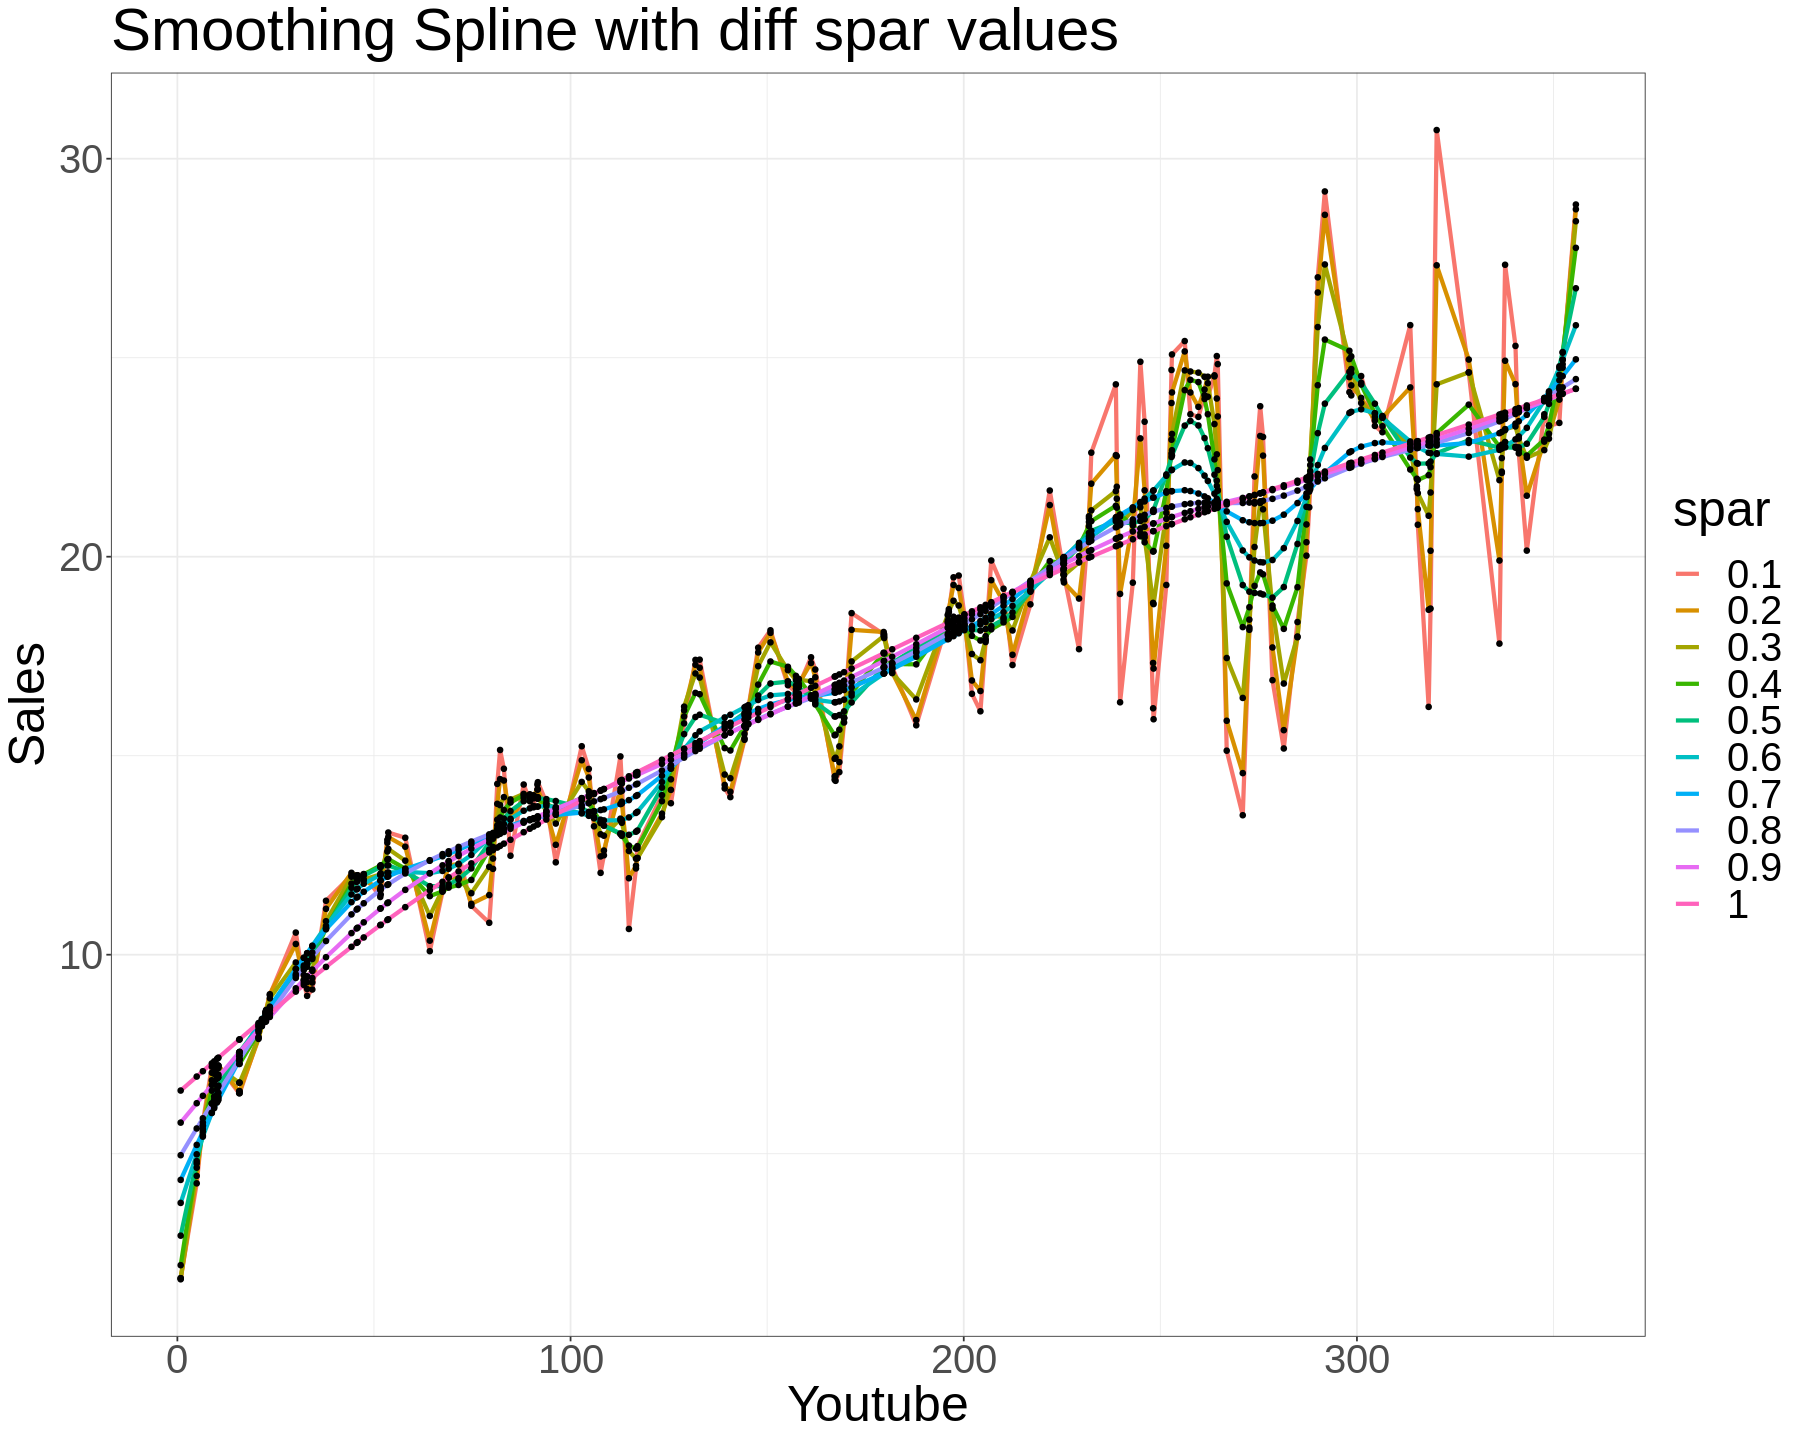

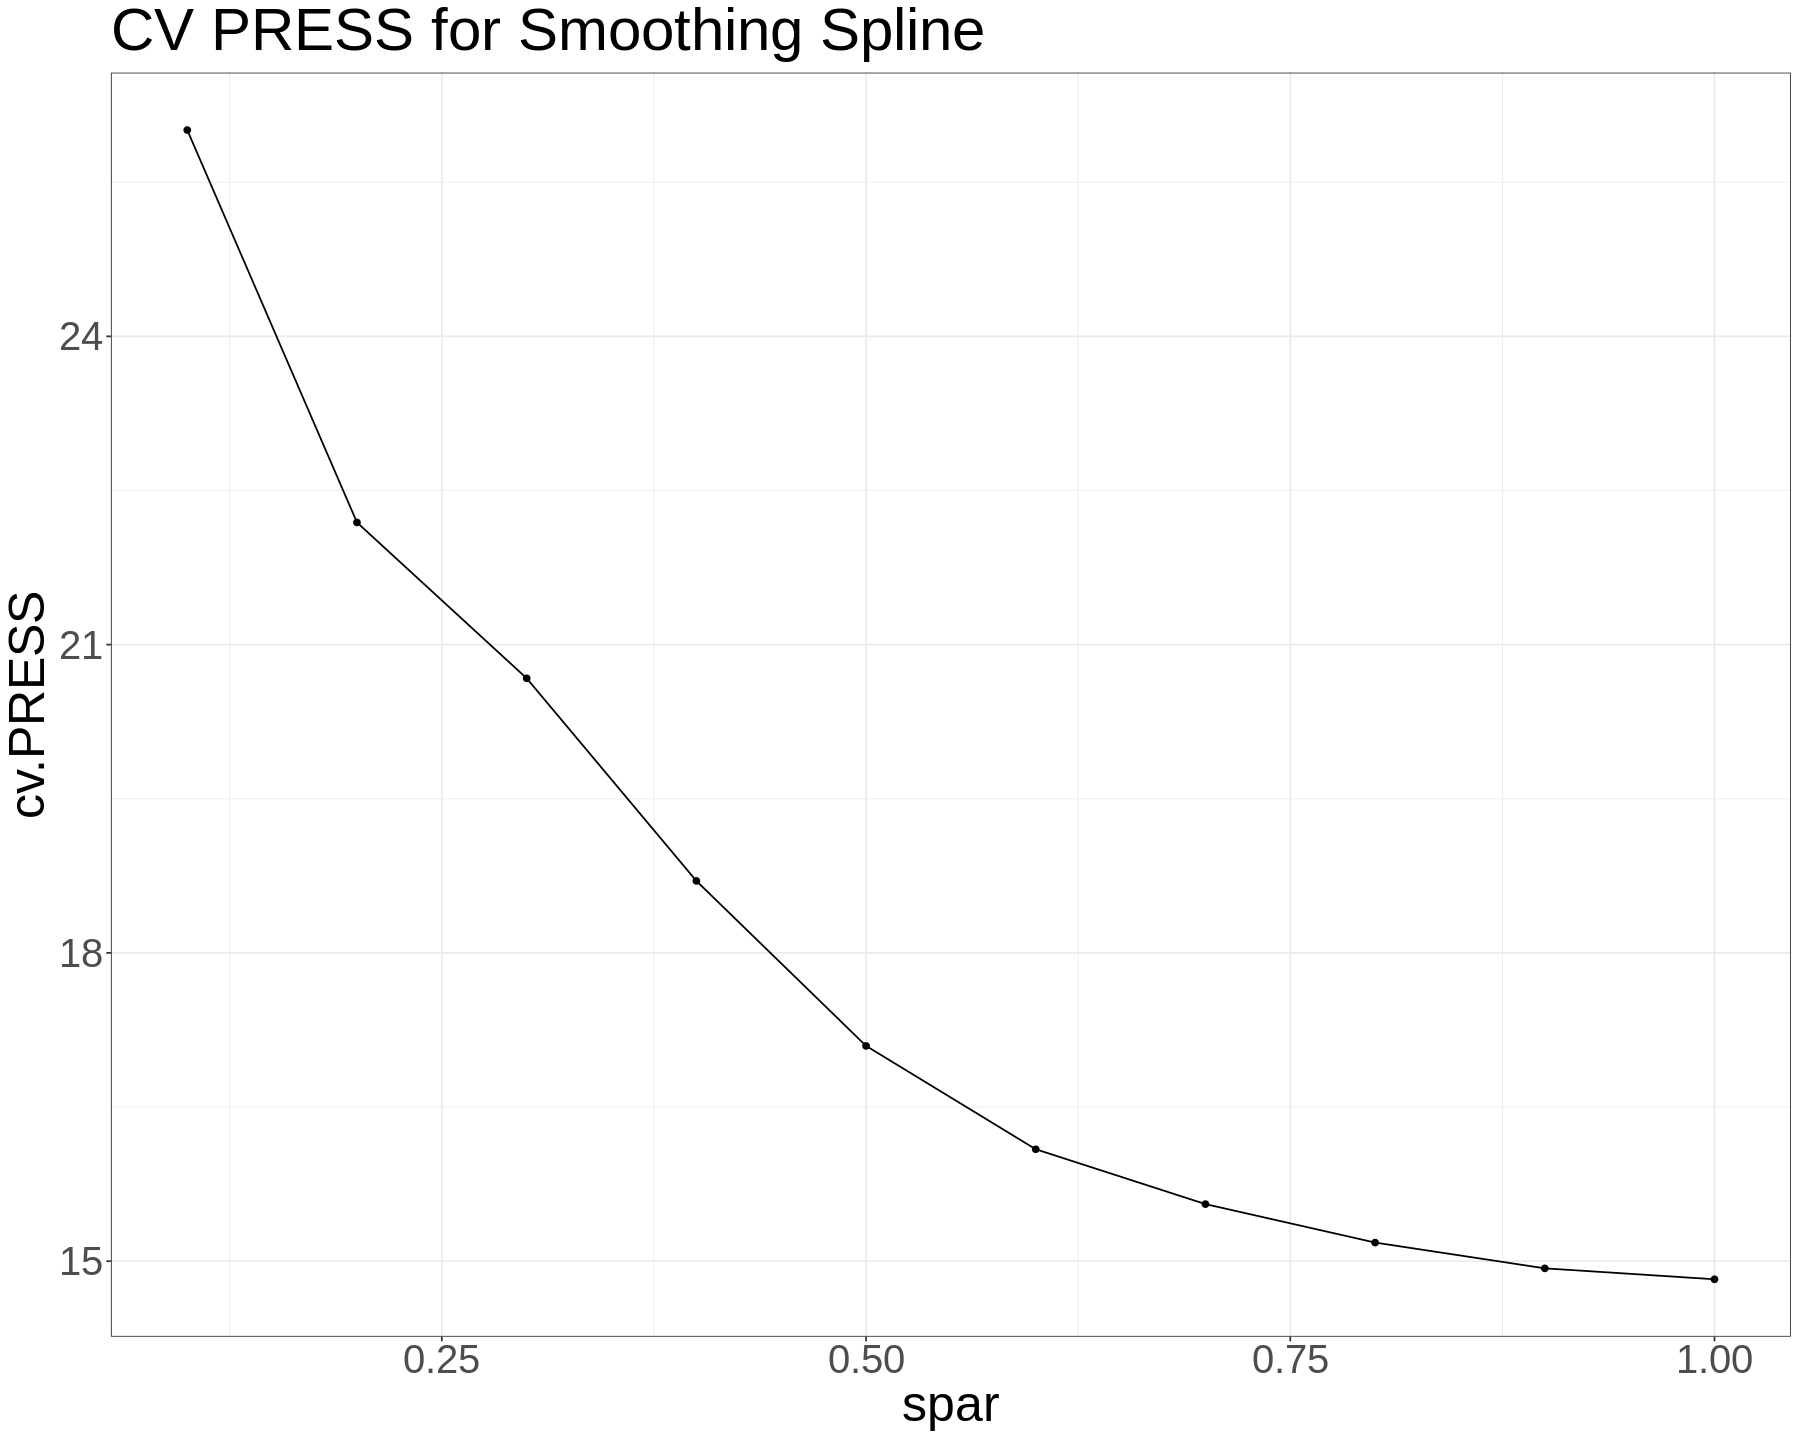

In [320]:
options(warn=-1)

spline.smooth <- function(x, y, spars) {
      plot.df <- NULL
      test.df <- NULL
      for (spar in spars) {
          res <- smooth.spline(x, y, spar = spar, cv = TRUE)
          #train_rmse <- sqrt(sum((res$y - y)^2))
          plot.df <- rbind(plot.df, data.frame(x=res$x, fitted.y=res$y, spar=spar))
          test.df <- rbind(test.df, data.frame(spar=spar, cv.PRESS=res$cv.crit))
      }
      plot.df$spar = as.factor(as.character(plot.df$spar))
      p <- ggplot(plot.df, aes(x, fitted.y)) + 
           geom_line(aes(col=spar), lwd=1.2) + geom_point(size=1.2) + 
           xlab('Youtube') + ylab('Sales') +
           theme_bw() +
           theme(text=element_text(size=30)) + 
           ggtitle('Smoothing Spline with diff spar values')
      print(p)
      #print(p, vp=grid::viewport(width=unit(5, 'inch'), height=unit(8, 'inch')))
      return (test.df)
}

test.df <- spline.smooth(x, y, spars = seq(0.1, 1, 0.1)) #seq(0.05,1,0.05))
ggplot(test.df, aes(spar, cv.PRESS)) + 
    geom_line() + geom_point() + 
    theme_bw() + theme(text=element_text(size=30)) +
    ggtitle('CV PRESS for Smoothing Spline')
#test.df

**1.(c) Working with nonlinearity: Loess**

Again, using the `train_marketing` set, plot `sales` (response) against `youtube` (predictor). This time, fit and overlay a loess regression model. You can use the `loess()` function in a similar way as the `lm()` function. Experiment with the smoothing parameter (`span` in the `geom_smooth()` function) until the smooth looks appropriate. Explain why it's appropriate and justify your answer.

### Answer:

The function `loess.smooth()` defined in the next code snippet accepts the training and test dataset, along with `spans` (smoothing) hyperparameter, it iterates over a list of values, fits a Loess model on the training dataset with a given `span` value at a time and uses the `predict()` function on test dataset, using which it computes the test **RMSE** values for the fitted model. 

The function also plots the fitted values corresponding to kernel regression models with different `span` values, as shown in the next plot. we choose `span`=$0.17$ as the appropriate value using the fitted curve, the model seems to start **overfitting** severely for the hyperparameter value greater than this and starts **underfitting** severely for value less than this.

As we can see from the second plot below, the **test RMSE** also becomes lowest around `span` value $0.2$. 

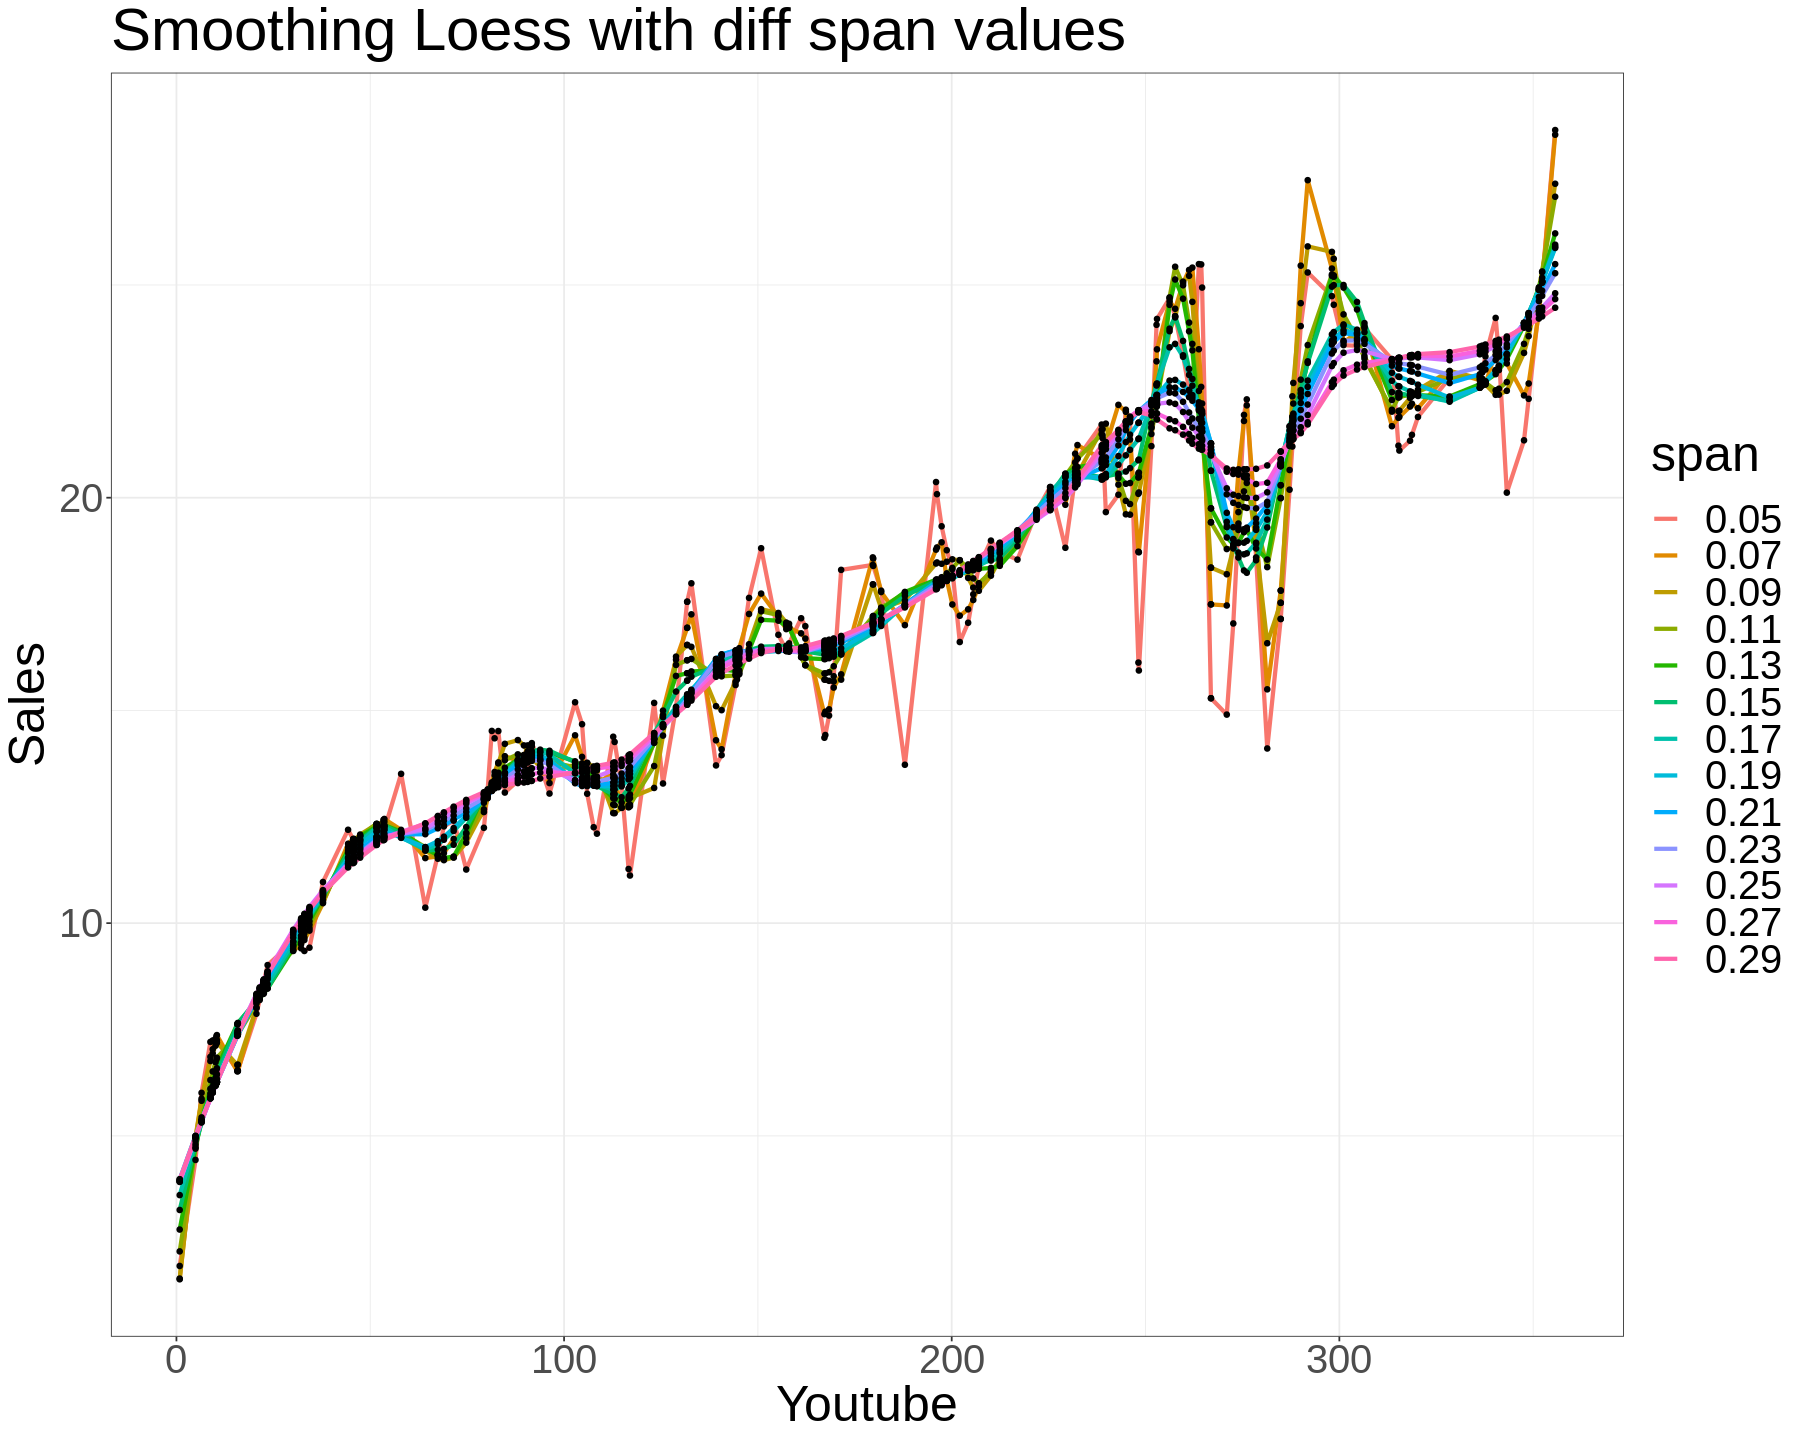

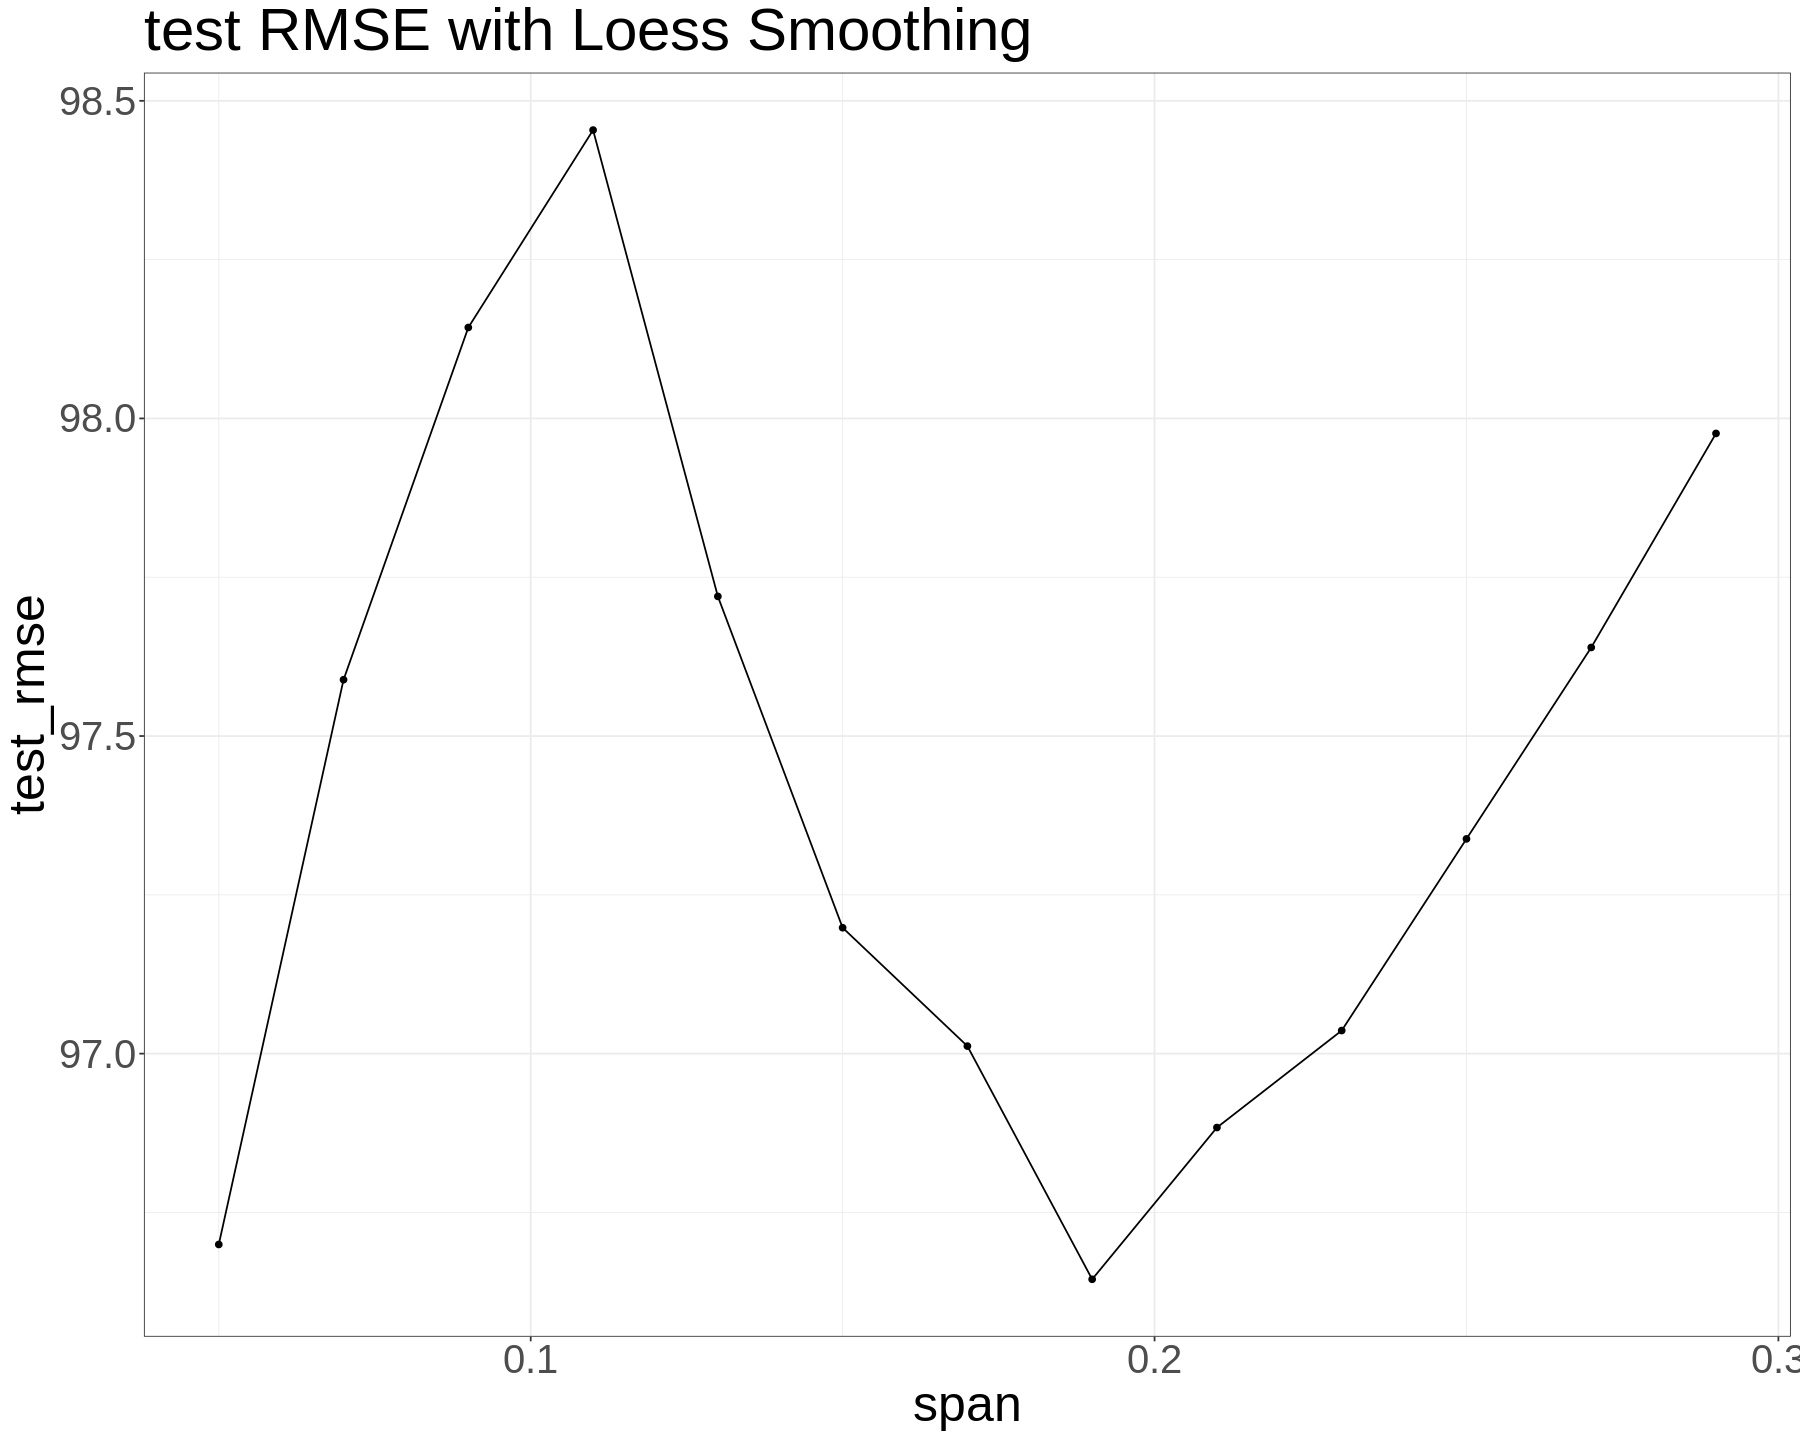

In [323]:
loess.smooth <- function(x, y, testx, testy, degree, spans) {
      plot.df <- NULL
      test.df <- NULL
      for (span in spans) {
          model <- loess(y ~ x, span = span, degree = degree)
          train_rmse <- sqrt(sum((model$fitted - y)^2))
          plot.df <- rbind(plot.df, data.frame(x=x, fitted.y=model$fitted, span=span))
          y.pred <- predict(model, data.frame(x = testx)) #, se = TRUE
          test_rmse <- sqrt(sum((y.pred - y)^2))
          test.df <- rbind(test.df, data.frame(span=span, train_rmse=train_rmse, test_rmse=test_rmse))
      }
      plot.df$span = as.factor(as.character(plot.df$span))
      p <- ggplot(plot.df, aes(x, fitted.y)) + 
           geom_line(aes(col=span), lwd=1.2) + geom_point(size=1.2) + 
           xlab('Youtube') + ylab('Sales') +
           theme_bw() +
           theme(text=element_text(size=30)) + 
           ggtitle('Smoothing Loess with diff span values')
      print(p)
      #print(p, vp=grid::viewport(width=unit(5, 'inch'), height=unit(8, 'inch')))
      return (test.df)
}

test.df <- loess.smooth(x, y, testx, testy, degree = 2, spans = seq(0.05, 0.3, 0.02))
ggplot(test.df, aes(span, test_rmse)) + 
    geom_line() + geom_point() + 
    theme_bw() + theme(text=element_text(size=30)) +
    ggtitle('test RMSE with Loess Smoothing')

We can use `geom_smooth()` function too with different `span` values for visualization and finding the appropriate value of the smoothing hyperparameter `span` for Loess, as shown below.

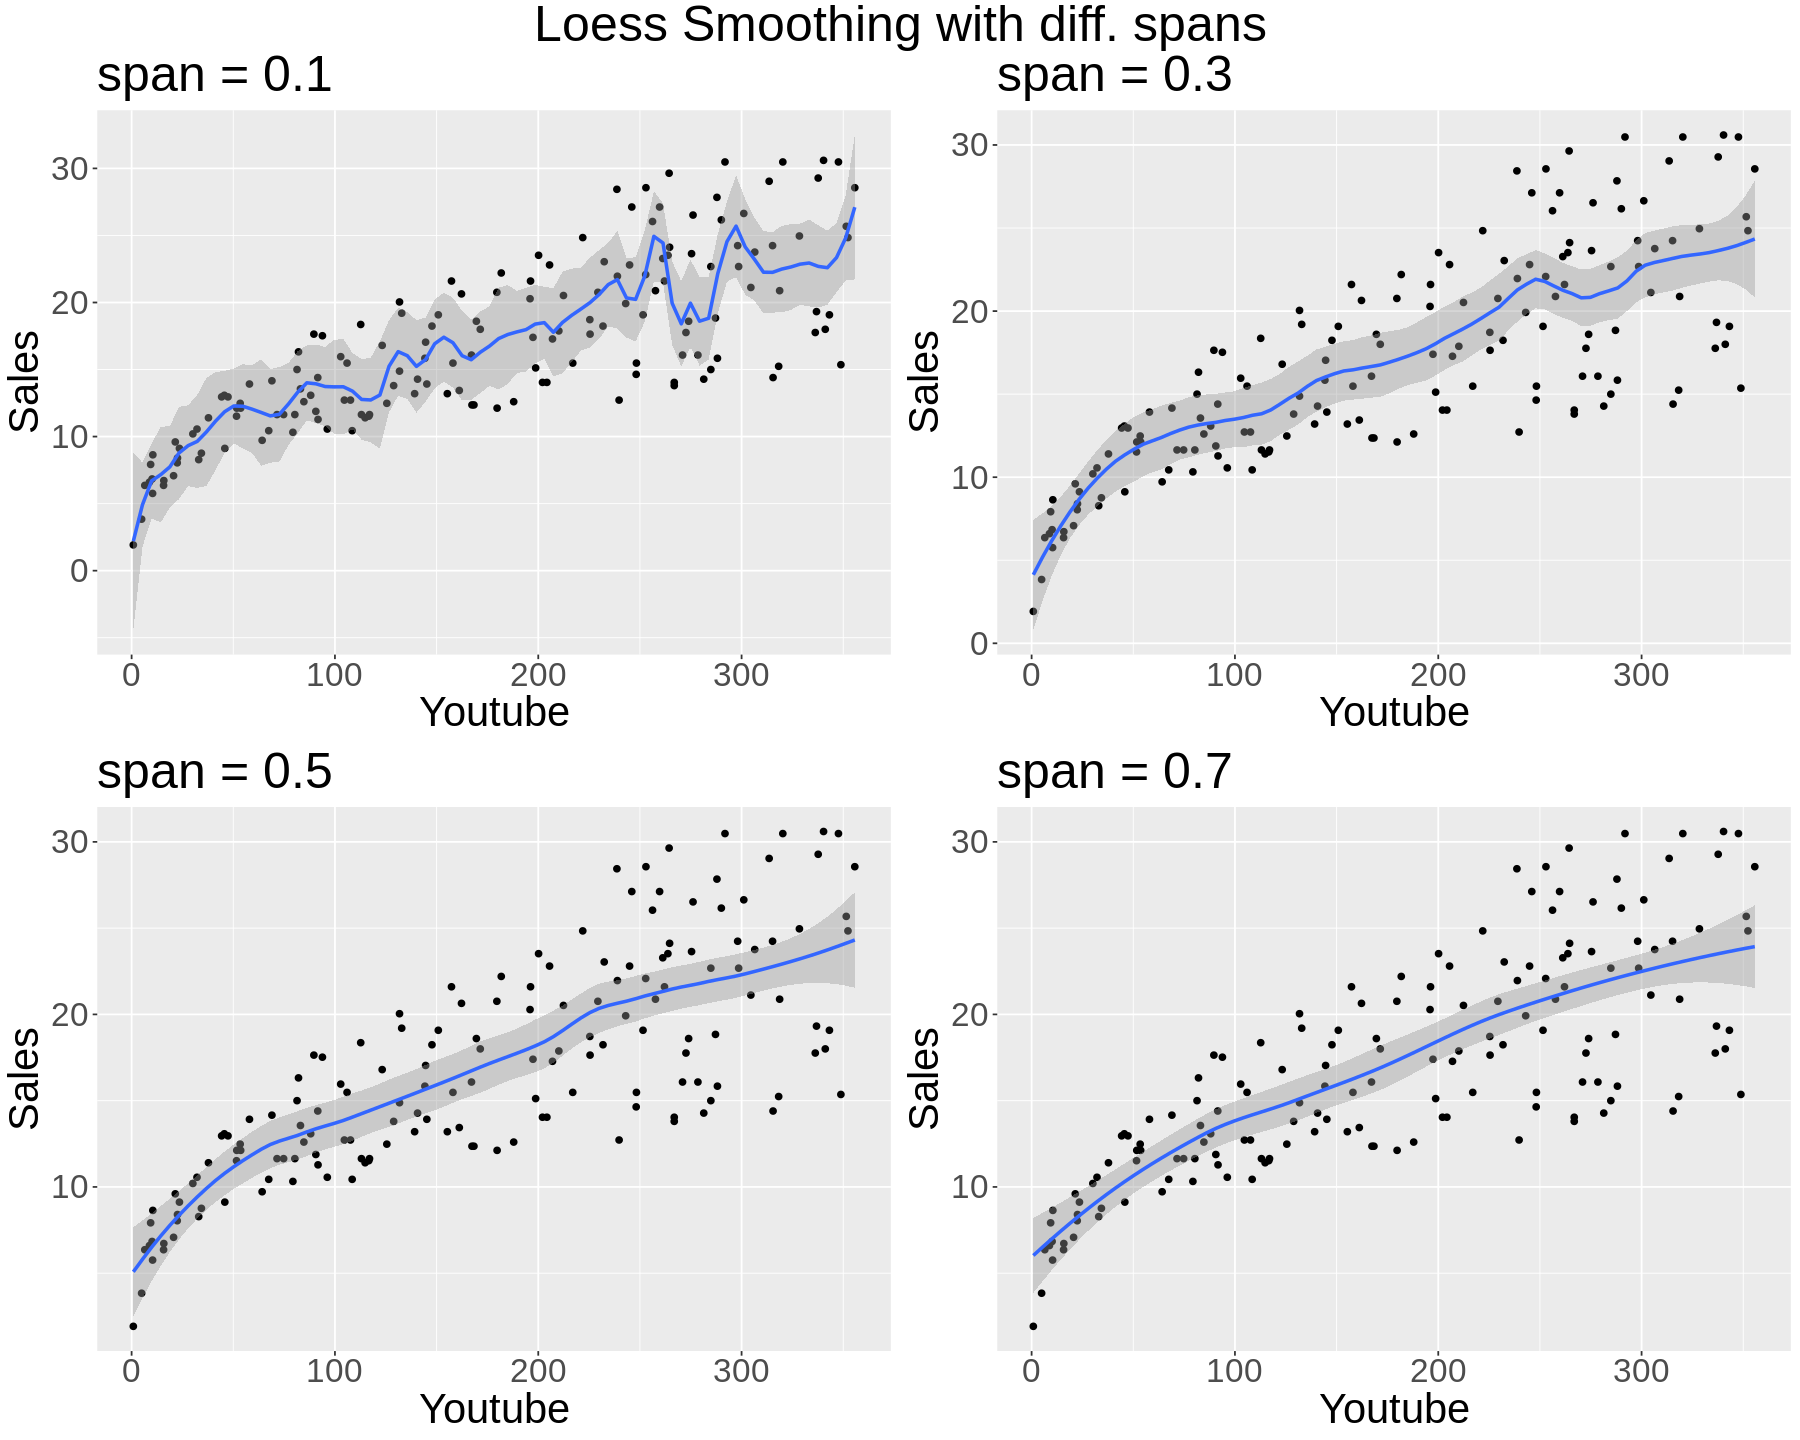

In [334]:
library(grid)
library(gridExtra)

plot.loess <- function(x, y, span) {
    df <- data.frame(x = x, y = y)
    p <- ggplot(df, aes(x, y)) + geom_point() + geom_smooth(formula=y~x, method='loess', span = span)
    p <- p + theme(text=element_text(size=25)) + ggtitle(paste('span =', span)) 
    p <- p + xlab('Youtube') + ylab('Sales')
    p
}
p1 <- plot.loess(x, y, 0.1)
p2 <- plot.loess(x, y, 0.3)
p3 <- plot.loess(x, y, 0.5)
p4 <- plot.loess(x, y, 0.7)
grid.arrange(p1, p2, p3, p4, top=textGrob("Loess Smoothing with diff. spans",gp=gpar(fontsize=30)))

**1.(d) A prediction metric**

Compare the models using the mean squared prediction error (MSPE) on the `test_marketing` dataset. That is, calculate the MSPE for your kernel regression, smoothing spline regression, and loess model, and identify which model is best in terms of this metric.

Remember, the MSPE is given by 

\begin{align*}
MSPE = \frac{1}{k}\sum^k_{i=1}\left(y^\star_i - \widehat{y}^\star_i \right)^2 
\end{align*}

where $y^\star_i$ are the observed response values in the test set and $\widehat{y}^\star_i$ are the predicted values for the test set (using the model fit on the training set).

\*Note that `ksmooth()` orders your designated `x.points`. Make sure to account for this in your MSPE calculation.

### Answer:

Let's now use the appropriate hyperparameter values found by looking at the fitted values using different smoothing models and fit the corresponding models for prediction on the test dataset and compute the **MSPE** values, as shown in the next visualization and the table of **MSPE** values. 

As can be seen, the **Loess Smoothing** performs the **best** with the **lowest MSPE** value $18.894$.

MSPE.kern,MSPE.spline,MSPE.loess
<dbl>,<dbl>,<dbl>
69.6526,55.94747,18.8943


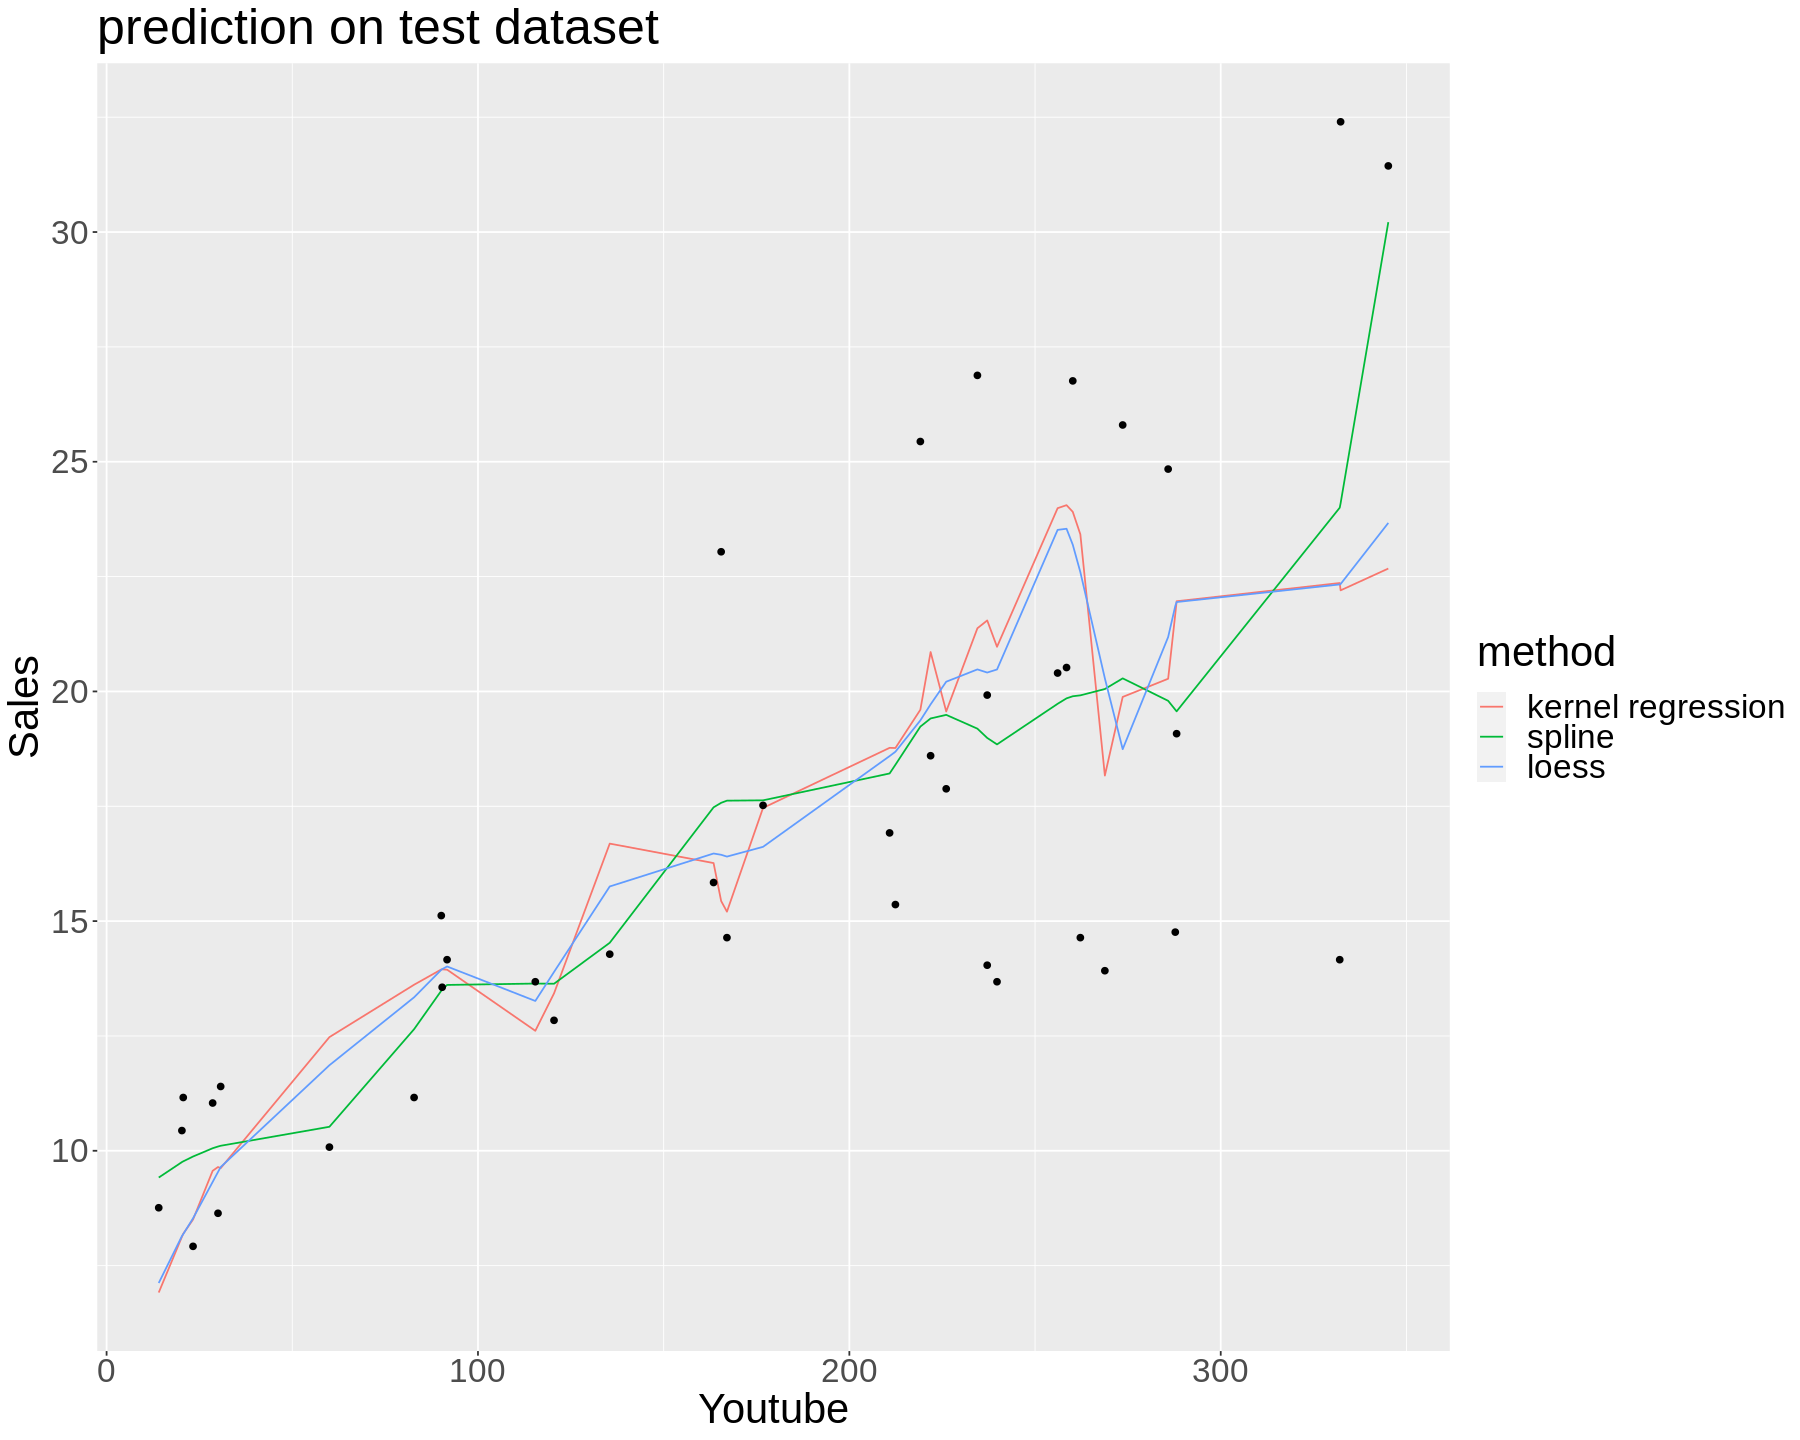

In [333]:
df.pred <- NULL

res.kern <- ksmooth(x, y, kernel = 'normal', bandwidth = 8, x.points = testx)
MSPE.kern <- mean((testy - res.kern$y)^2)

df.pred <- rbind(df.pred, data.frame(x = res.kern$x, y.fitted = res.kern$y, method = 'kernel regression'))

res.spline <- smooth.spline(testx, testy, spar = 0.6)
MSPE.spline <- mean((testy - res.spline$y)^2)

df.pred <- rbind(df.pred, data.frame(x = res.spline$x, y.fitted = res.spline$y, method = 'spline'))

model.loess <- loess(y ~ x, span = 0.17, degree = 2)
testy.pred <- predict(model.loess, data.frame(x = testx))
MSPE.loess <- mean((testy - testy.pred)^2)

df.pred <- rbind(df.pred, data.frame(x = testx, y.fitted = testy.pred, method = 'loess'))
#head(df.pred)

df.test <- data.frame(x = testx, y = testy)

ggplot(df.pred) + geom_line(aes(x, y.fitted, color=method)) +
    geom_point(data = df.test, aes(x, y)) +
    xlab('Youtube') + ylab('Sales') +
    theme(text=element_text(size=25)) + ggtitle('prediction on test dataset') 

data.frame(MSPE.kern, MSPE.spline, MSPE.loess)

# Problem 2: Simulations!

Simulate data (one predictor and one response) with your own nonlinear relationship. Provide an explanation of how you generated the data. Then answer the questions above (1.(a) - 1.(d)) using your simulated data.

### Answers:

As seen from below, the predictor variable $x$ is drawn from a sequence of numbers equally spaced and the response variable $y$ is generated by applying the non-linear periodic funcion `sine` on $x$ and adding some i.i.d. uniform random noise to it using the function `runif()`. For reproducibility of the results, let's set a ranom seed `1`, before pseudorandom number generation.

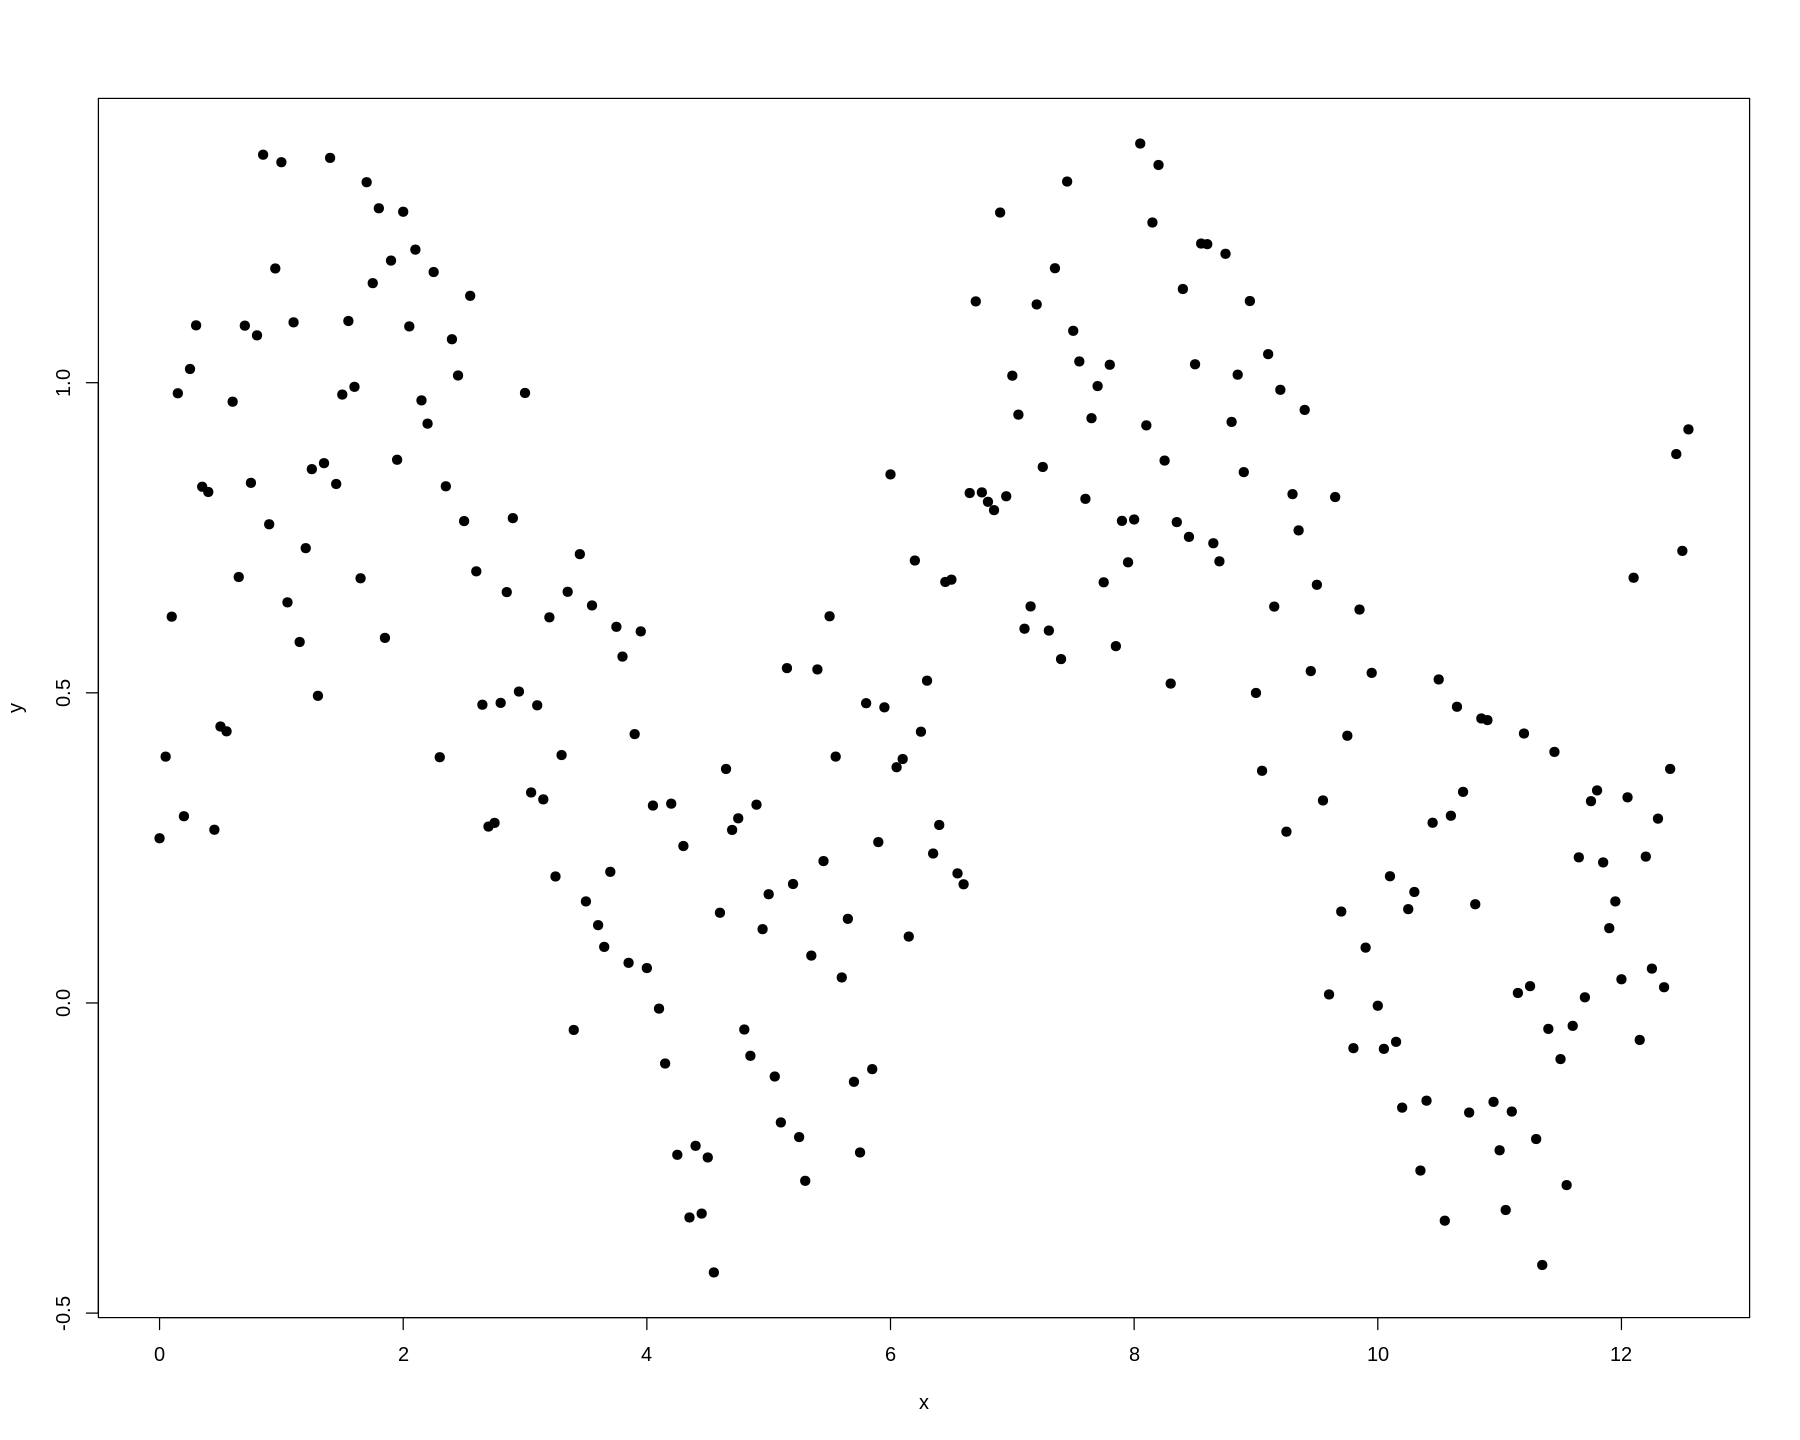

In [285]:
#simulated data
set.seed(1)
x = seq(0, 4*pi, 0.05)
y = 0.5*sin(x) + runif(length(x))
plot(x, y, pch=19)

In [286]:
set.seed(1771) #set the random number generator seed.
n = floor(0.8 * length(x)) #find the number corresponding to 80% of the data
index = sample(seq_len(length(x)), size = n) #randomly sample indicies to be included in the training set
trainx = x[index] #set the training set to be the randomly sampled rows of the dataframe
trainy = y[index]
testx = x[-index] #set the testing set to be the remaining rows
testy = y[-index]
length(testx) #check the dimensions
length(trainx) #check the dimensions

[1] 51

[1] 201

Now, let's find the kernel regression model that looks ok from the visualization after fitting on the training data, here we choose the model with `bandwidth=0.6`, considering the **bias-variance tradeoff**, as done last time.

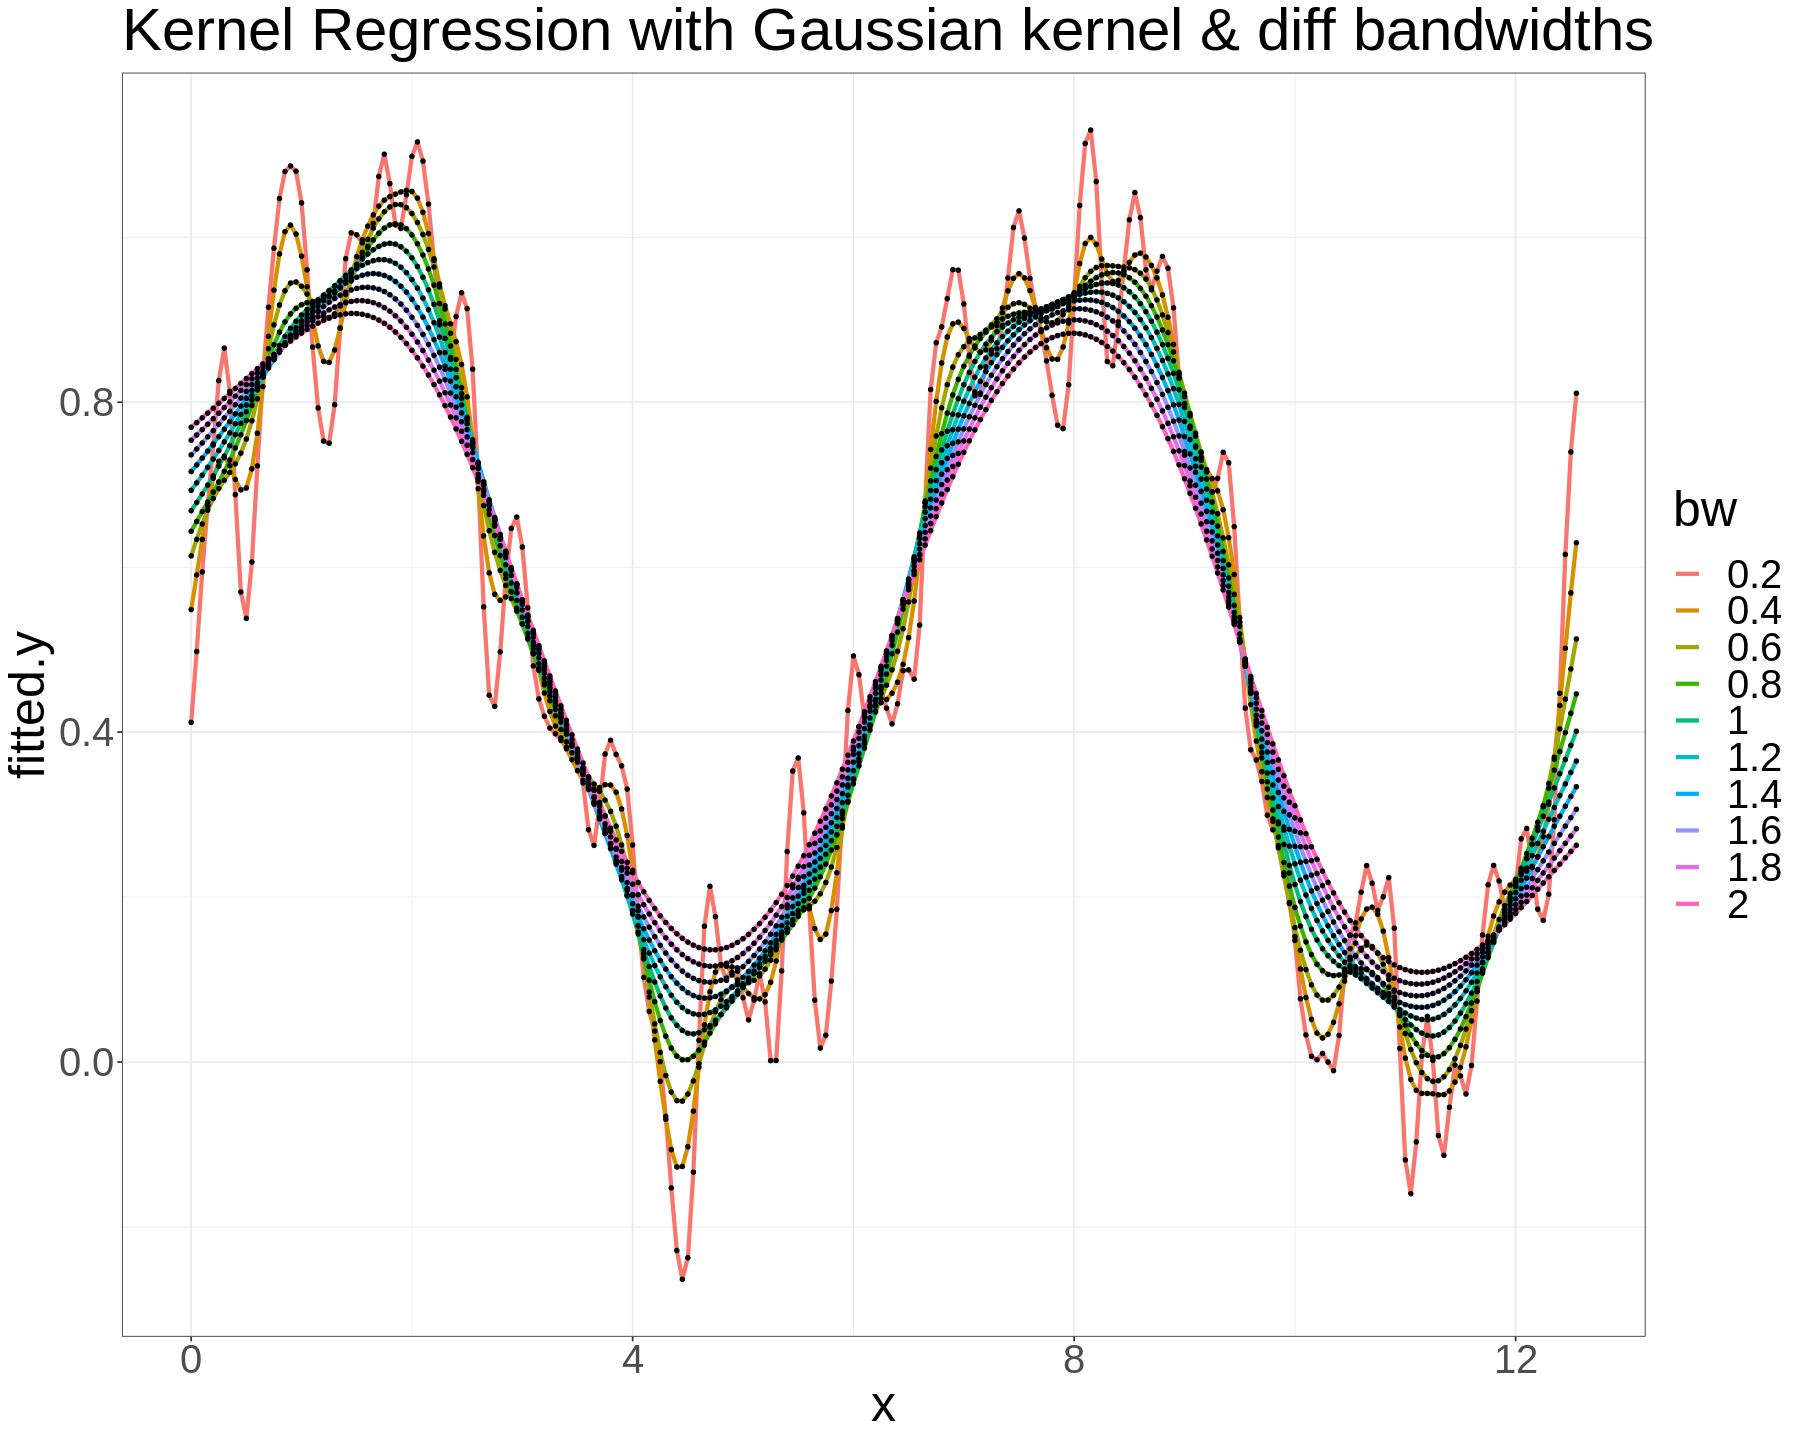

In [287]:
#1.a
test.df <- kernel.regression(x, y, testx, testy, kernel = 'normal', bws = seq(0.2,2,0.2)) 

Again, let's find the smoothing spline model that looks ok from the visualization after fitting on the training data, here we choose the model with `spar=0.25`, considering the **bias-variance tradeoff**, as done last time.

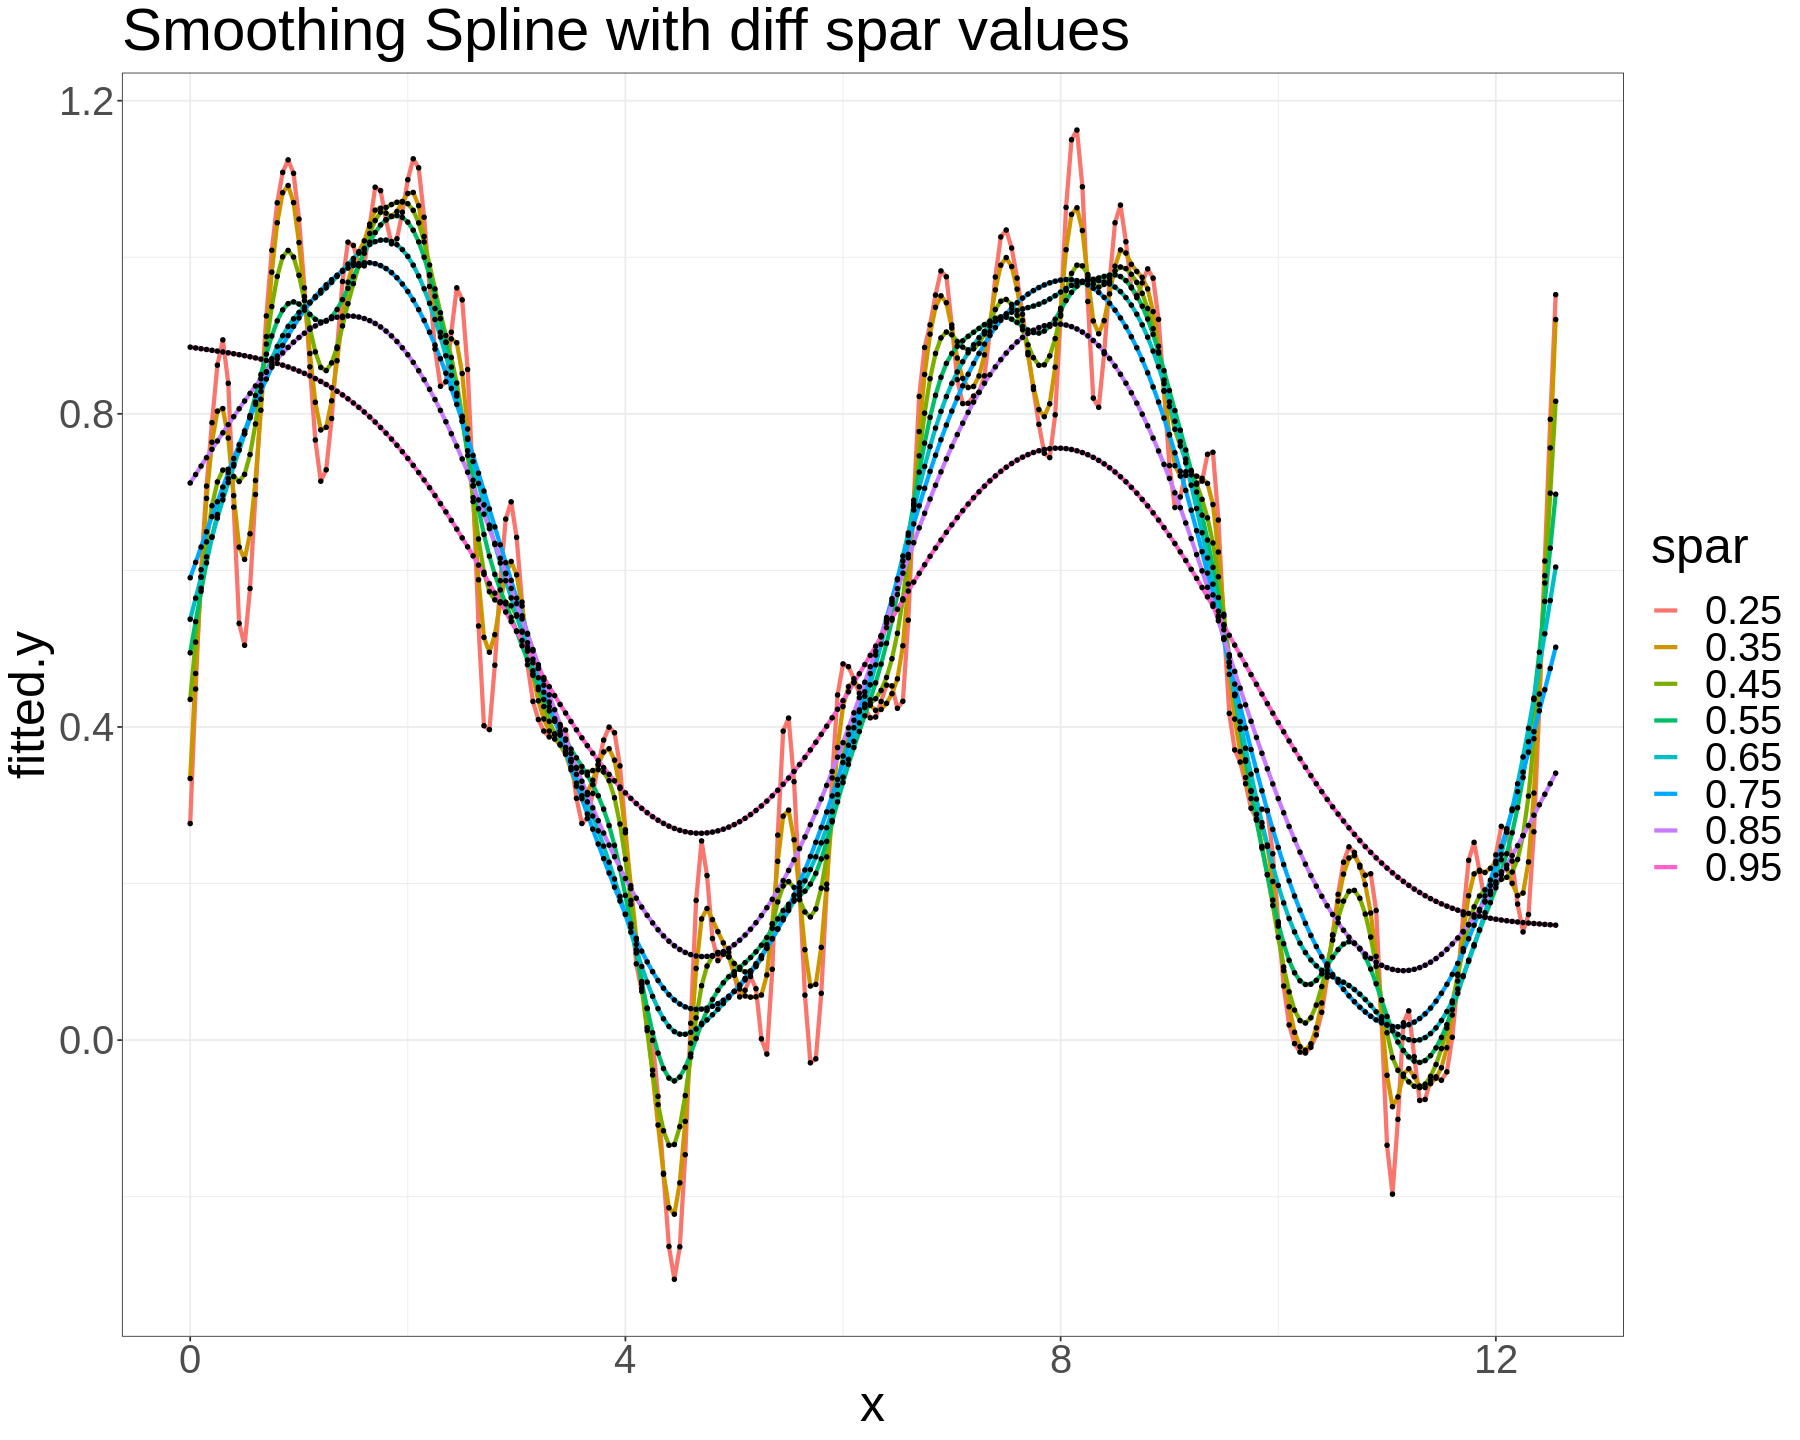

In [288]:
#1.b
test.df <- spline.smooth(x, y, spars = seq(0.25, 1, 0.1)) #seq(0.05,1,0.05))

Finally, let's find the Loess smoothing model that looks ok from the visualization after fitting on the training data, here we choose the model with `span=0.4`, considering the **bias-variance tradeoff**, as done last time.

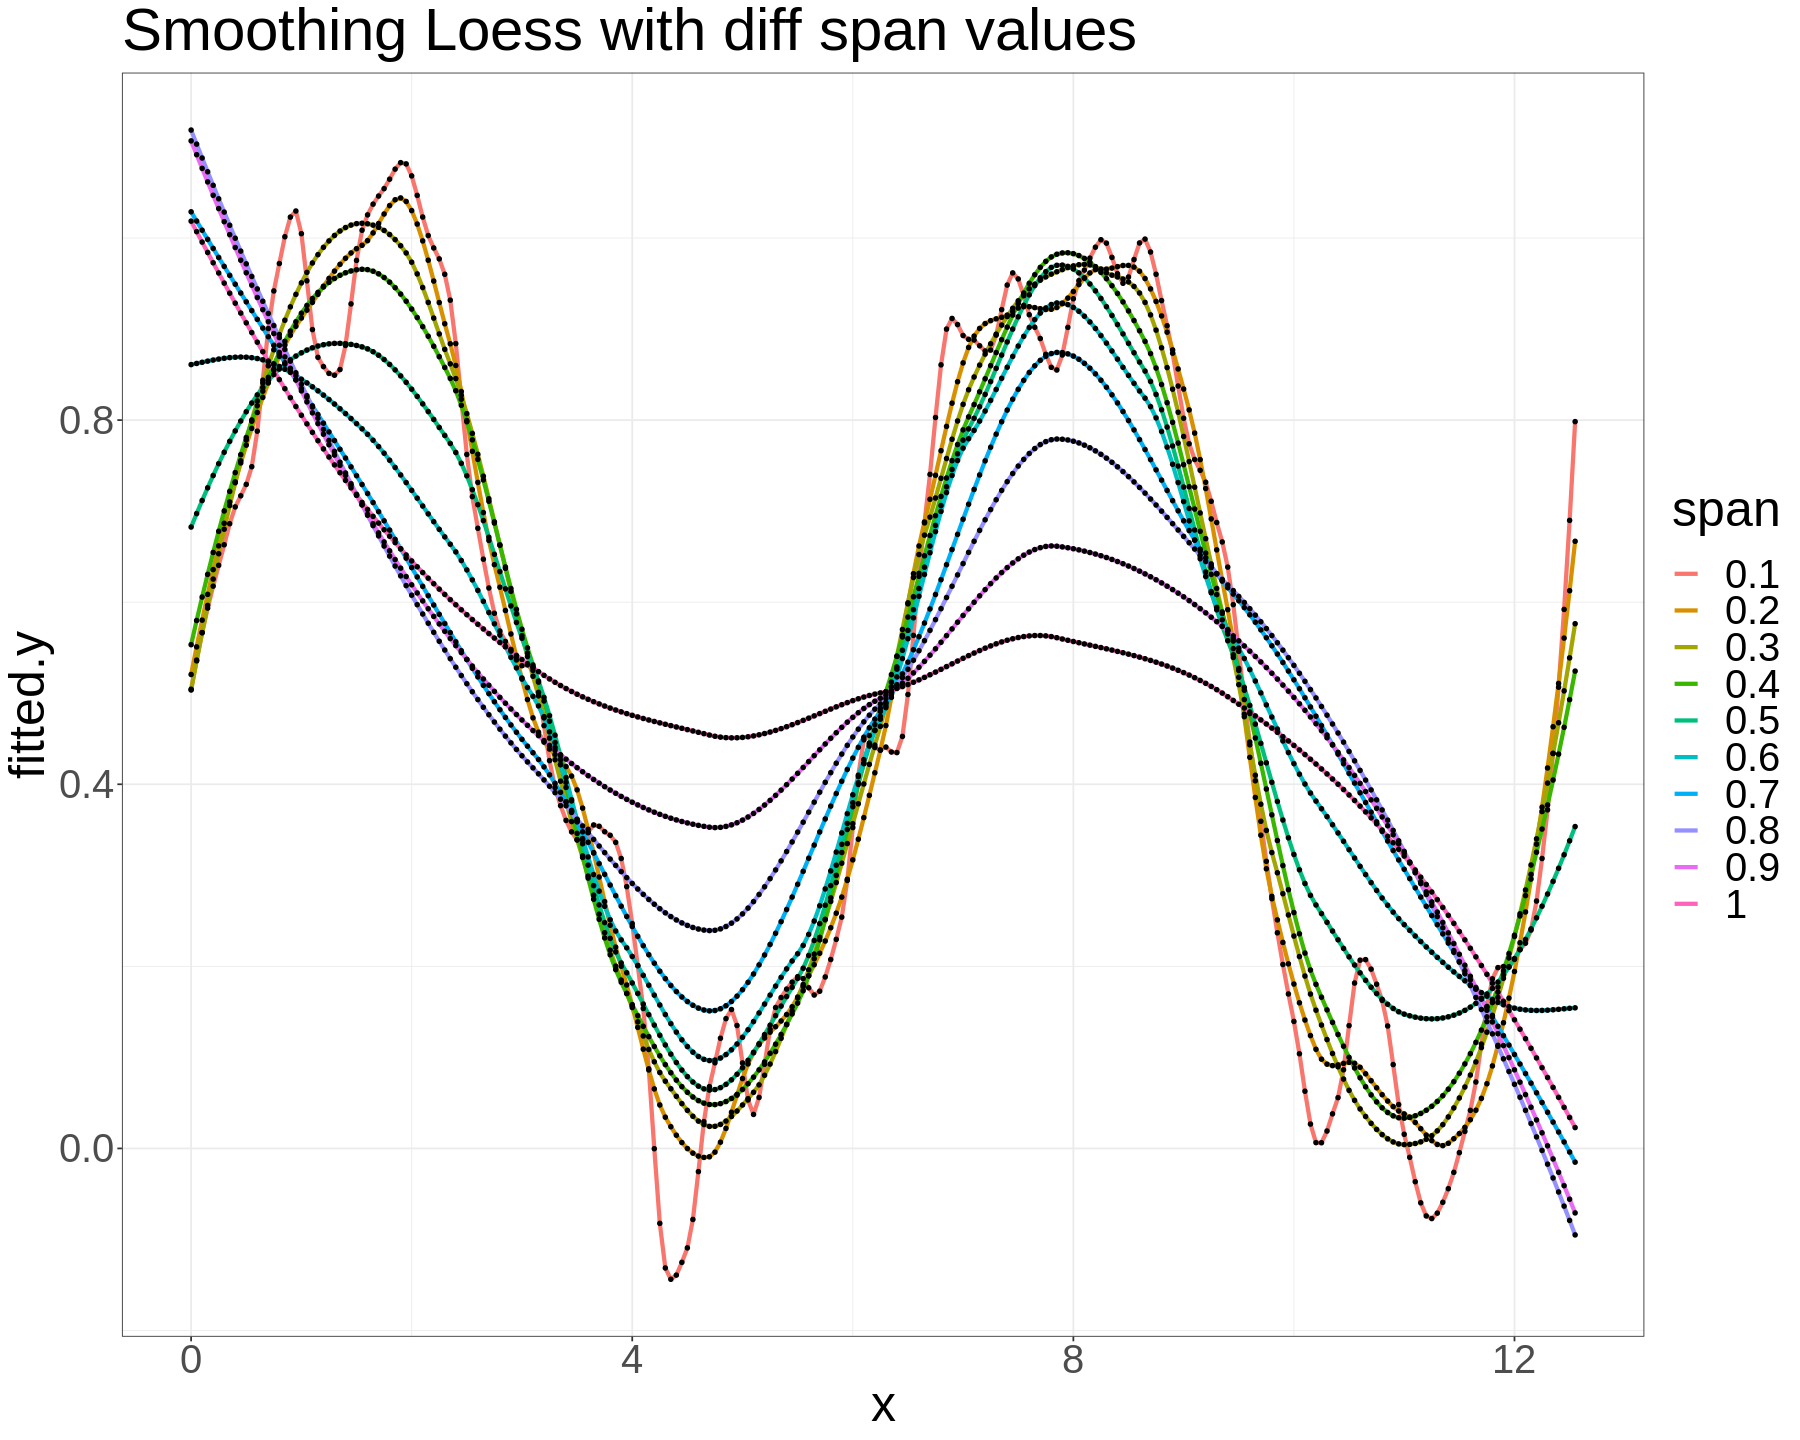

In [290]:
#1.c
test.df <- loess.smooth(x, y, degree = 2, spans = seq(0.1, 1, 0.1))

Lets compute the **test MSPE** values using the prediction of the chosen nonlinear models. As can be seen, this time the **smoothing spline** moel performs the best, with the lowest **MPSE** on test dataset = $0.034$.

MSPE.kern,MSPE.spline,MSPE.loess
<dbl>,<dbl>,<dbl>
0.05767093,0.03391682,0.06272934


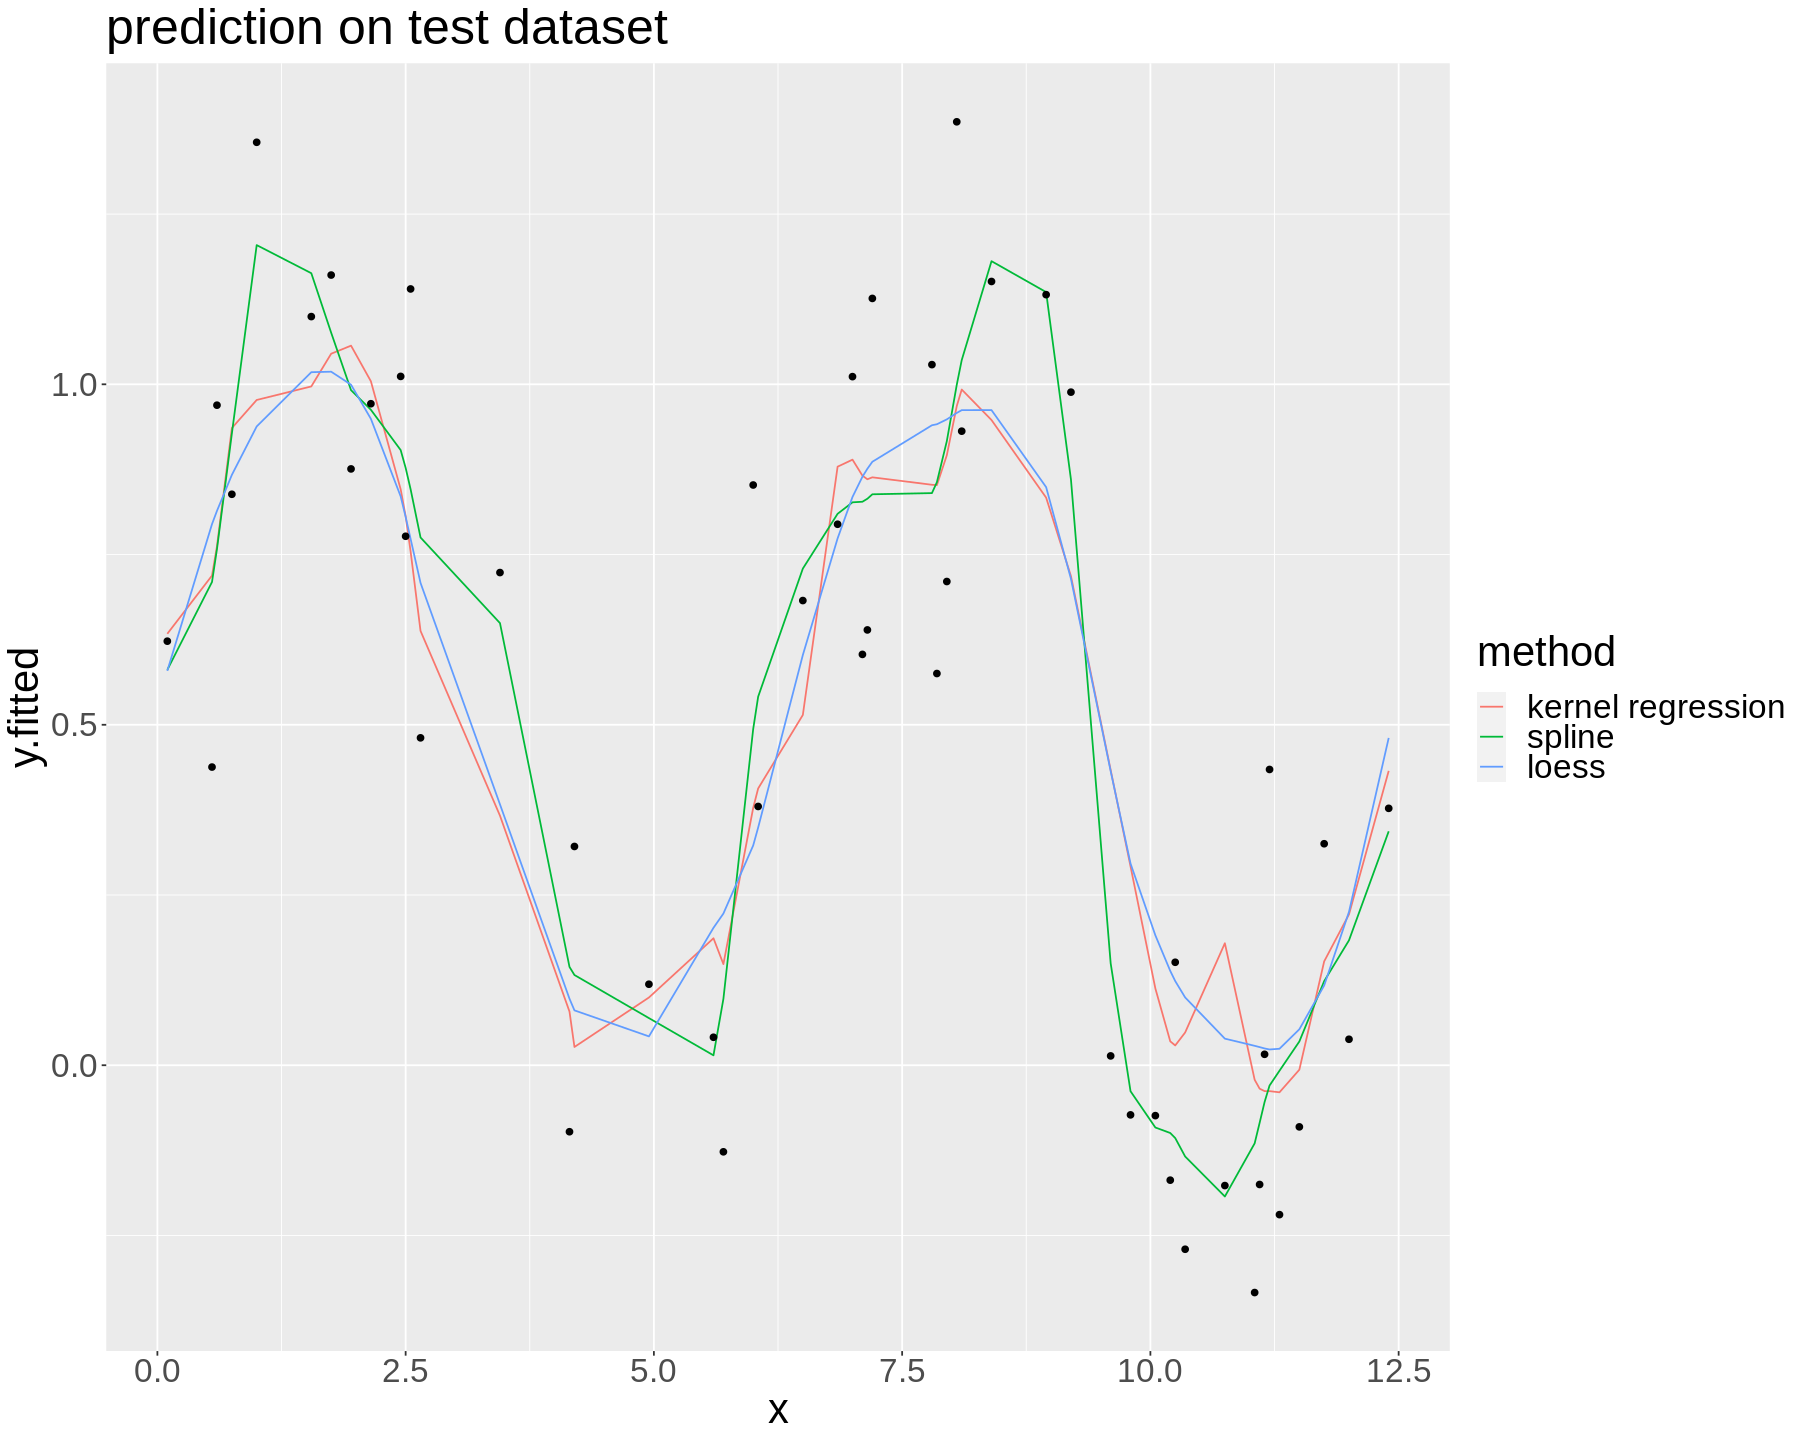

In [291]:
#1.d
df.pred <- NULL

res.kern <- ksmooth(x, y, kernel = 'normal', bandwidth = 0.4, x.points = testx)
MSPE.kern <- mean((testy - res.kern$y)^2)

df.pred <- rbind(df.pred, data.frame(x = res.kern$x, y.fitted = res.kern$y, method = 'kernel regression'))

res.spline <- smooth.spline(testx, testy, spar = 0.5)
MSPE.spline <- mean((testy - res.spline$y)^2)

df.pred <- rbind(df.pred, data.frame(x = res.spline$x, y.fitted = res.spline$y, method = 'spline'))

model.loess <- loess(y ~ x, span = 0.25, degree = 2)
testy.pred <- predict(model.loess, data.frame(x = testx))
MSPE.loess <- mean((testy - testy.pred)^2)

df.pred <- rbind(df.pred, data.frame(x = testx, y.fitted = testy.pred, method = 'loess'))
#head(df.pred)

df.test <- data.frame(x = testx, y = testy)

ggplot(df.pred) + geom_line(aes(x, y.fitted, color=method)) +
    geom_point(data = df.test, aes(x, y)) +
    theme(text=element_text(size=25)) + ggtitle('prediction on test dataset') 

data.frame(MSPE.kern, MSPE.spline, MSPE.loess)